In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pioii
import plotly.subplots as sp


In [2]:
df_uncleaned = pd.read_csv('data/uncleaned_data.csv', encoding='latin-1')

In [3]:
df_uncleaned

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/01/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/01/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/01/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/01/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/01/10 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/09/11 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/09/11 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/09/11 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/09/11 12:50,4.15,12680.0,France


In [4]:
df_uncleaned.dtypes
df_uncleaned.isnull().sum()
df_uncleaned.describe()
df_uncleaned.info()
df_uncleaned.shape
df_uncleaned.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [5]:
df_uncleaned['InvoiceDate'] = pd.to_datetime(df_uncleaned['InvoiceDate'])

df_uncleaned['CustomerID'] = df_uncleaned['CustomerID'].astype('Int64')

df_uncleaned['Country'] = df_uncleaned['Country'].astype('category')

df_uncleaned.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              Int64
Country              category
dtype: object

In [6]:
df_uncleaned.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
pd.DataFrame({
    'total_count': df_uncleaned.count(),
    'distinct_count': df_uncleaned.nunique()
})

,total_count,distinct_count
InvoiceNo,541909,25900
StockCode,541909,4070
Description,540455,4223
Quantity,541909,722
InvoiceDate,541909,23260
UnitPrice,541909,1630
CustomerID,406829,4372
Country,541909,38


In [8]:
distinct_count_df = df_uncleaned.nunique()

In [9]:
distinct_count_df

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

## Missing Values

I always start here. Before any analysis, I need to know what's missing and how bad it is. CustomerID nulls are the biggest concern, if a row has no customer, I can't tie it to any behavioral analysis later. Description nulls matter less since I still have StockCode.

/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/pandas/plotting/_matplotlib/tools.py:400: MatplotlibDeprecationWarning: 
The is_first_col function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_first_col() instead.
  if ax.is_first_col():


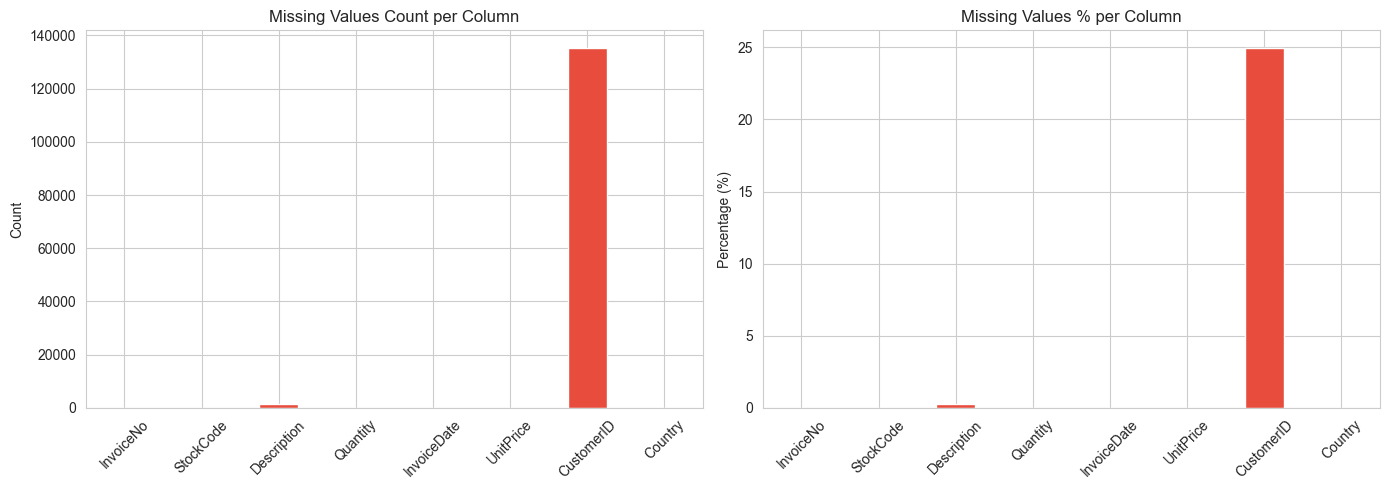

             Missing Count  Missing %
CustomerID          135080      24.93
Description           1454       0.27


In [11]:
missing = df_uncleaned.isnull().sum()
missing_pct = (missing / len(df_uncleaned) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in df_uncleaned.isnull().sum()]
df_uncleaned.isnull().sum().plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Missing Values Count per Column')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

missing_pct.plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_title('Missing Values % per Column')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(missing_df)

## Distributions Check

I'm looking for red flags here, negative quantities (returns?), zero or negative prices (adjustments?), and extreme outliers. Messy data is expected at this stage. Stats here will tell me what cleaning rules I need.

In [12]:
df_uncleaned.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


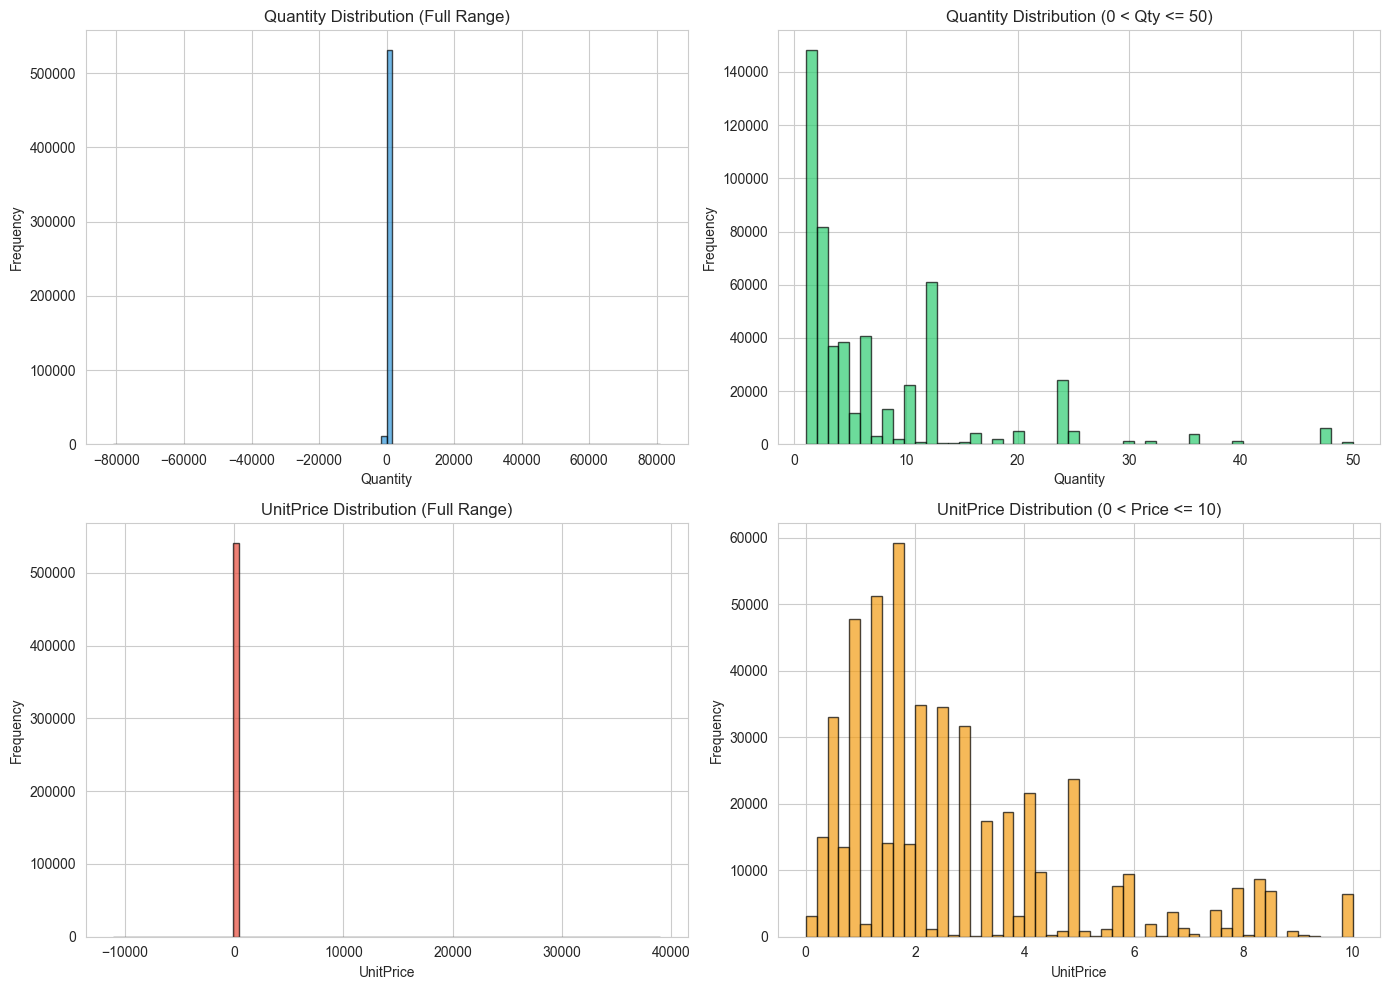

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df_uncleaned['Quantity'], bins=100, color='#3498db', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Quantity Distribution (Full Range)')
axes[0, 0].set_xlabel('Quantity')
axes[0, 0].set_ylabel('Frequency')

q_filtered = df_uncleaned[(df_uncleaned['Quantity'] > 0) & (df_uncleaned['Quantity'] <= 50)]
axes[0, 1].hist(q_filtered['Quantity'], bins=50, color='#2ecc71', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Quantity Distribution (0 < Qty <= 50)')
axes[0, 1].set_xlabel('Quantity')
axes[0, 1].set_ylabel('Frequency')

axes[1, 0].hist(df_uncleaned['UnitPrice'], bins=100, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('UnitPrice Distribution (Full Range)')
axes[1, 0].set_xlabel('UnitPrice')
axes[1, 0].set_ylabel('Frequency')

p_filtered = df_uncleaned[(df_uncleaned['UnitPrice'] > 0) & (df_uncleaned['UnitPrice'] <= 10)]
axes[1, 1].hist(p_filtered['UnitPrice'], bins=50, color='#f39c12', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('UnitPrice Distribution (0 < Price <= 10)')
axes[1, 1].set_xlabel('UnitPrice')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

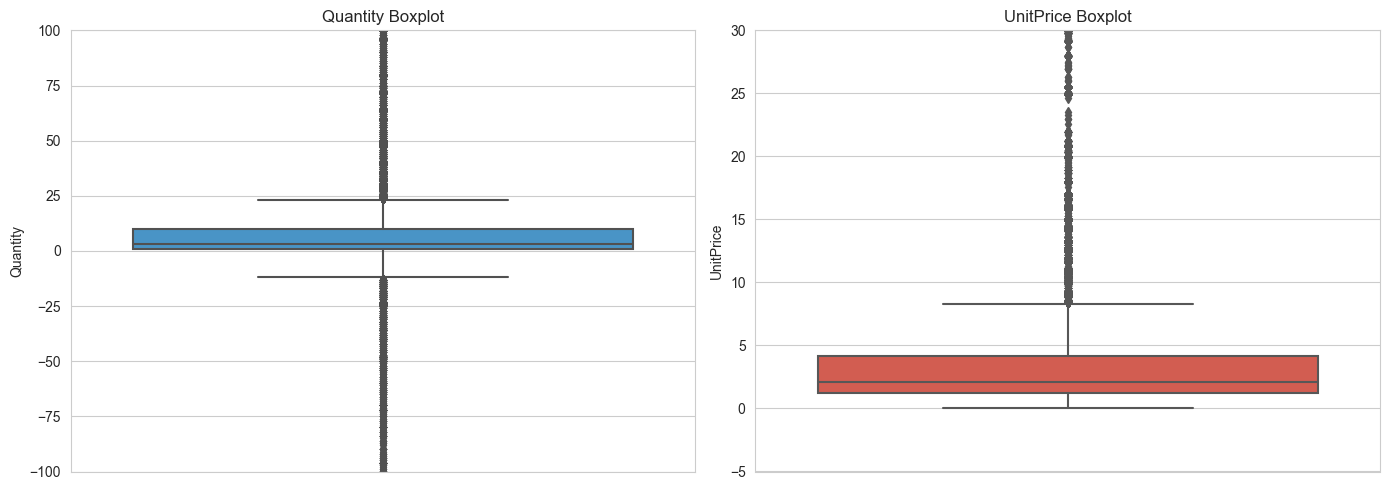

Quantity outliers (negative = returns):
  Negative quantities: 10,624
  Zero quantities:     0

UnitPrice anomalies:
  Zero prices:    2,515
  Negative prices: 2


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df_uncleaned['Quantity'], ax=axes[0], color='#3498db')
axes[0].set_title('Quantity Boxplot')
axes[0].set_ylim(-100, 100)

sns.boxplot(y=df_uncleaned['UnitPrice'], ax=axes[1], color='#e74c3c')
axes[1].set_title('UnitPrice Boxplot')
axes[1].set_ylim(-5, 30)

plt.tight_layout()
plt.show()

print("Quantity outliers (negative = returns):")
print(f"  Negative quantities: {(df_uncleaned['Quantity'] < 0).sum():,}")
print(f"  Zero quantities:     {(df_uncleaned['Quantity'] == 0).sum():,}")
print(f"\nUnitPrice anomalies:")
print(f"  Zero prices:    {(df_uncleaned['UnitPrice'] == 0).sum():,}")
print(f"  Negative prices: {(df_uncleaned['UnitPrice'] < 0).sum():,}")

## Revenue Breakdown

I want to see where the money actually comes from, which products, which customers, which countries dominate. Knowing the revenue split tells me whether the business is concentrated (a few whales) or broad. Concentration matters because it affects how I interpret churn and segmentation later.

In [15]:
df_uncleaned['Revenue'] = df_uncleaned['Quantity'] * df_uncleaned['UnitPrice']

print(f"Total Revenue: £{df_uncleaned['Revenue'].sum():,.2f}")
print(f"Average Order Value (per line item): £{df_uncleaned['Revenue'].mean():,.2f}")
print(f"Median Order Value (per line item): £{df_uncleaned['Revenue'].median():,.2f}")

Total Revenue: £9,747,747.93
Average Order Value (per line item): £17.99
Median Order Value (per line item): £9.75


/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/pandas/plotting/_matplotlib/tools.py:400: MatplotlibDeprecationWarning: 
The is_first_col function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_first_col() instead.
  if ax.is_first_col():


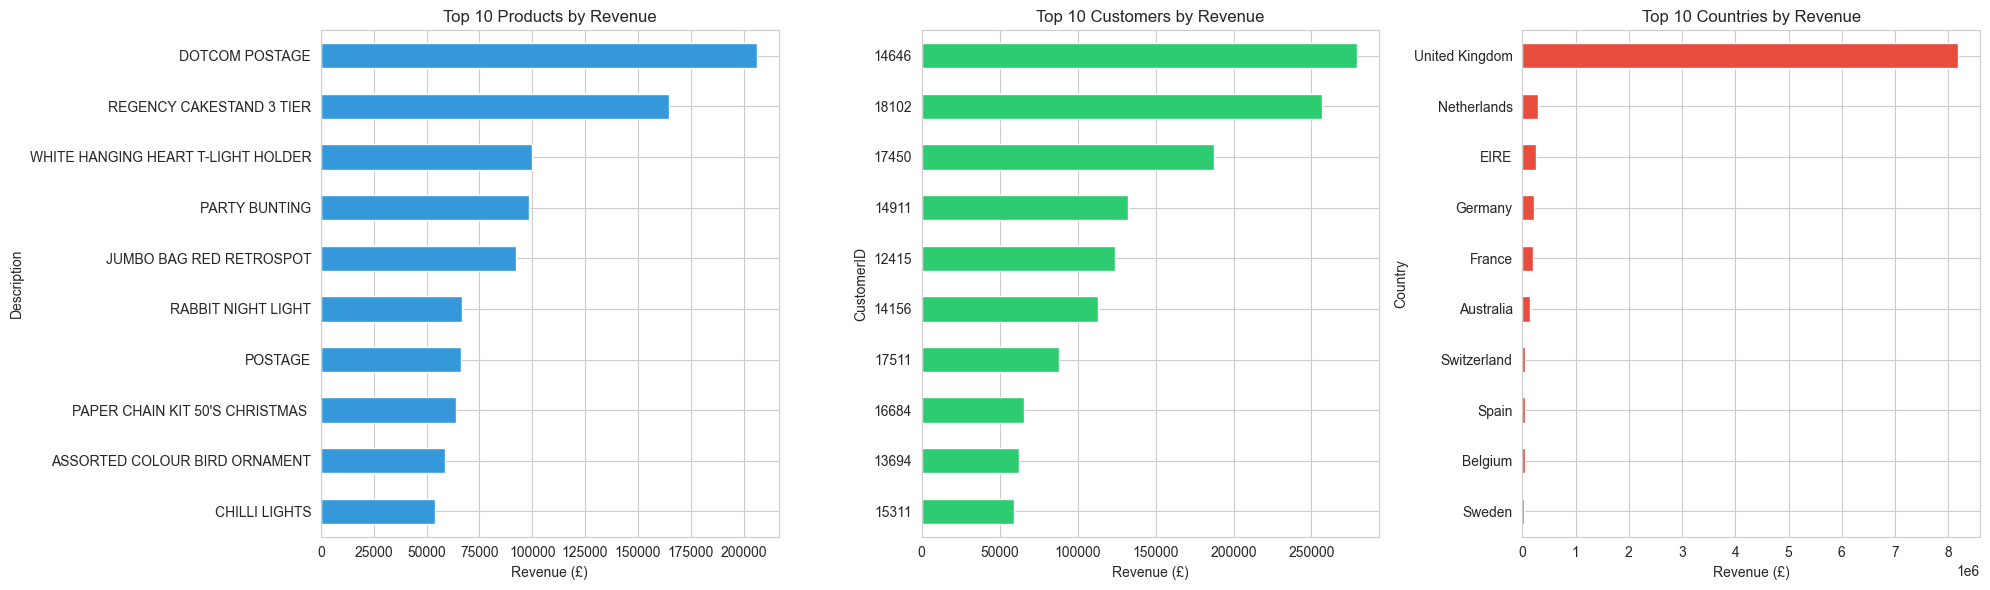

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

top_products = (df_uncleaned.groupby('Description')['Revenue']
                .sum().sort_values(ascending=False).head(10))
top_products.plot(kind='barh', ax=axes[0], color='#3498db')
axes[0].set_title('Top 10 Products by Revenue')
axes[0].set_xlabel('Revenue (£)')
axes[0].invert_yaxis()

top_customers = (df_uncleaned.groupby('CustomerID')['Revenue']
                 .sum().sort_values(ascending=False).head(10))
top_customers.index = top_customers.index.astype(str)
top_customers.plot(kind='barh', ax=axes[1], color='#2ecc71')
axes[1].set_title('Top 10 Customers by Revenue')
axes[1].set_xlabel('Revenue (£)')
axes[1].invert_yaxis()

top_countries = (df_uncleaned.groupby('Country')['Revenue']
                 .sum().sort_values(ascending=False).head(10))
top_countries.plot(kind='barh', ax=axes[2], color='#e74c3c')
axes[2].set_title('Top 10 Countries by Revenue')
axes[2].set_xlabel('Revenue (£)')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

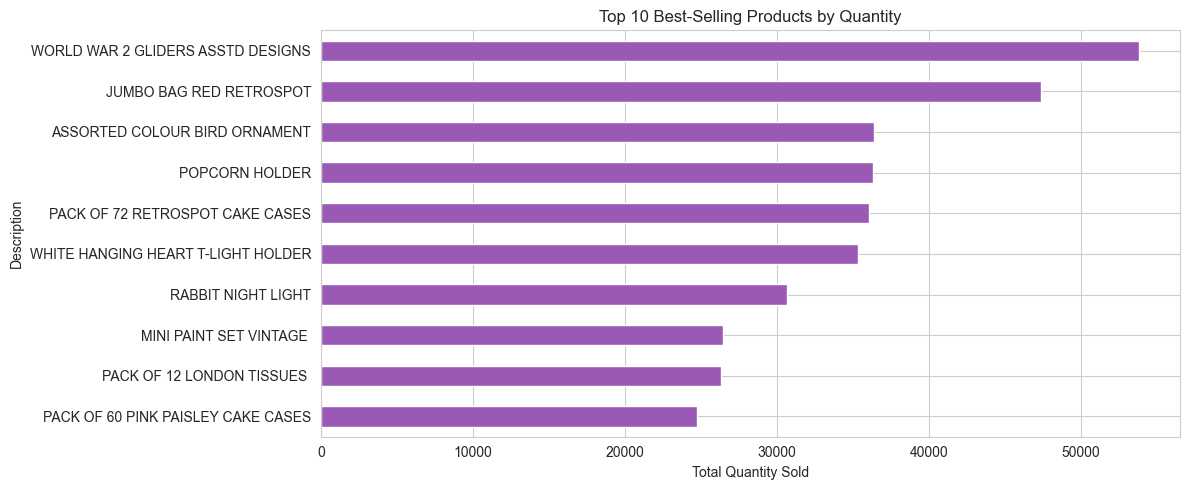

In [17]:
top_qty_products = (df_uncleaned.groupby('Description')['Quantity']
                    .sum().sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(12, 5))
top_qty_products.plot(kind='barh', ax=ax, color='#9b59b6')
ax.set_title('Top 10 Best-Selling Products by Quantity')
ax.set_xlabel('Total Quantity Sold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Sales Over Time

I need to understand seasonality before building any predictive model. If sales spike in December and drop in January, that's not churn, it's normal behavior. Monthly, daily, and hourly patterns each tell a different story.

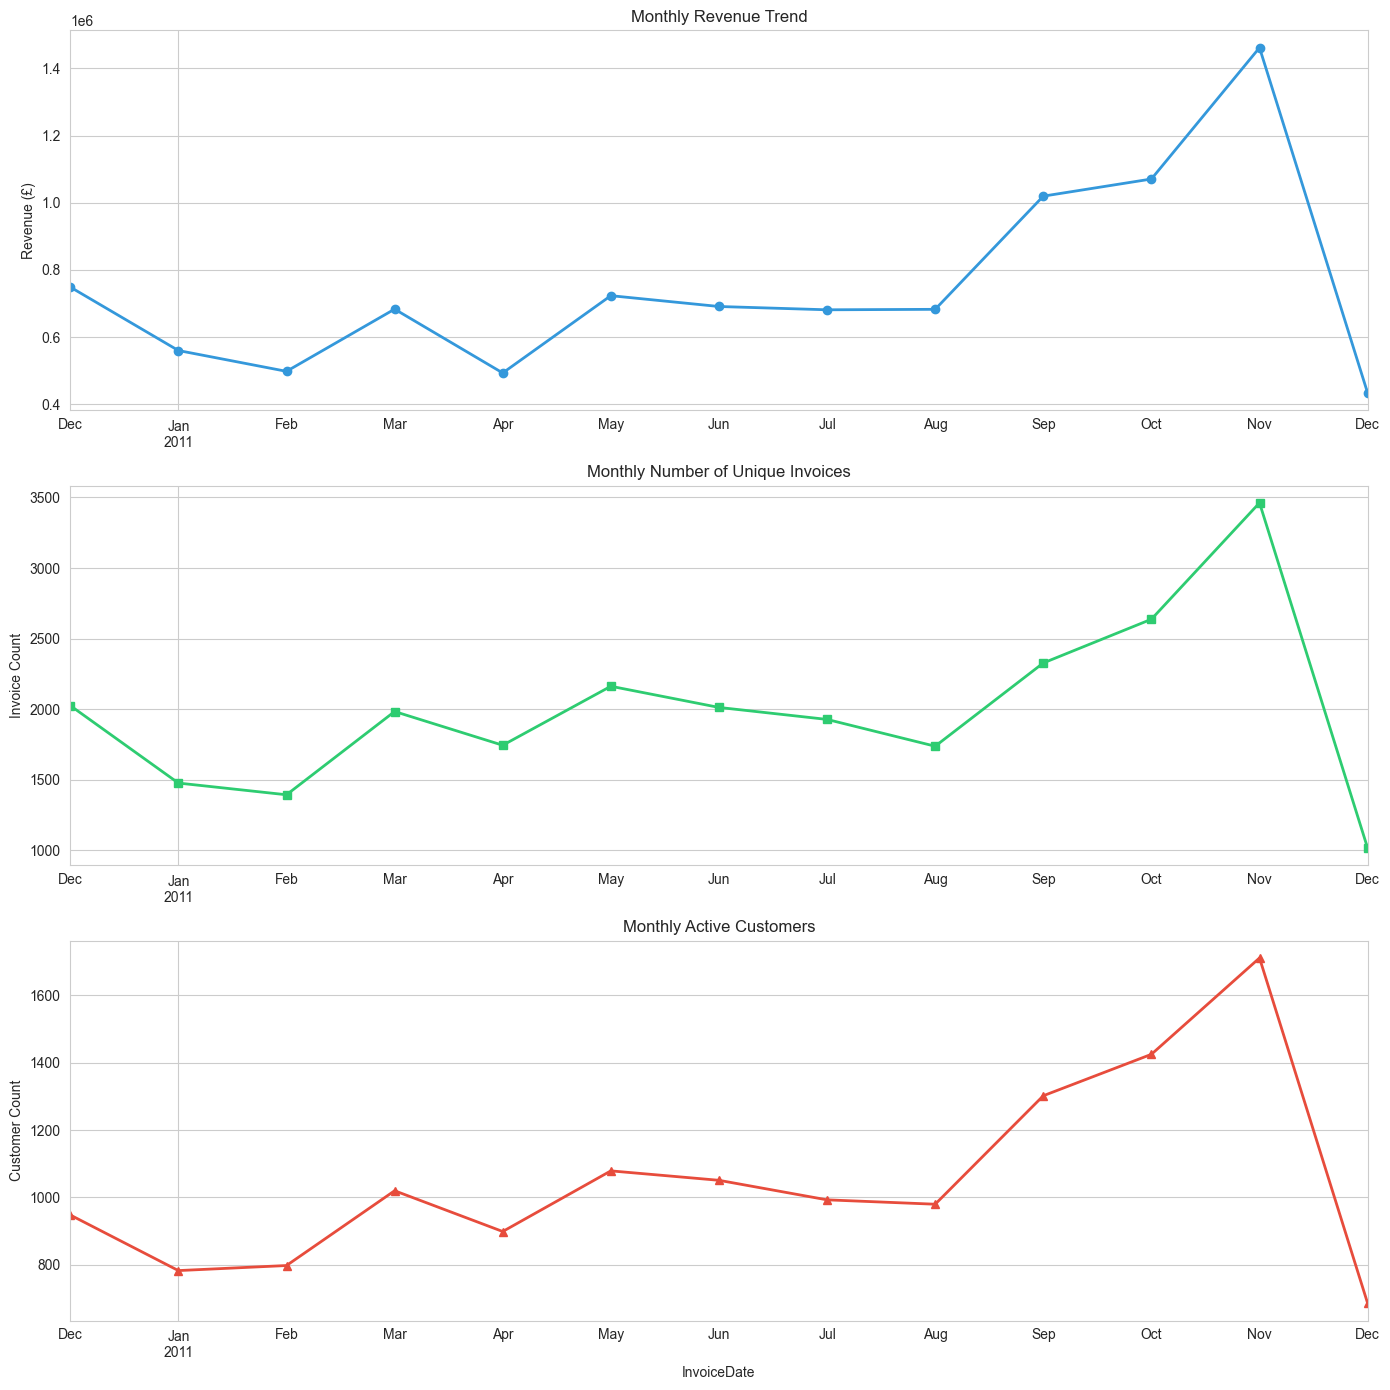

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

monthly_revenue = df_uncleaned.set_index('InvoiceDate')['Revenue'].resample('M').sum()
monthly_revenue.plot(ax=axes[0], marker='o', color='#3498db', linewidth=2)
axes[0].set_title('Monthly Revenue Trend')
axes[0].set_ylabel('Revenue (£)')
axes[0].set_xlabel('')

monthly_orders = df_uncleaned.set_index('InvoiceDate')['InvoiceNo'].resample('M').nunique()
monthly_orders.plot(ax=axes[1], marker='s', color='#2ecc71', linewidth=2)
axes[1].set_title('Monthly Number of Unique Invoices')
axes[1].set_ylabel('Invoice Count')
axes[1].set_xlabel('')

monthly_customers = df_uncleaned.dropna(subset=['CustomerID']).set_index('InvoiceDate')['CustomerID'].resample('M').nunique()
monthly_customers.plot(ax=axes[2], marker='^', color='#e74c3c', linewidth=2)
axes[2].set_title('Monthly Active Customers')
axes[2].set_ylabel('Customer Count')

plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/pandas/plotting/_matplotlib/tools.py:400: MatplotlibDeprecationWarning: 
The is_first_col function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_first_col() instead.
  if ax.is_first_col():


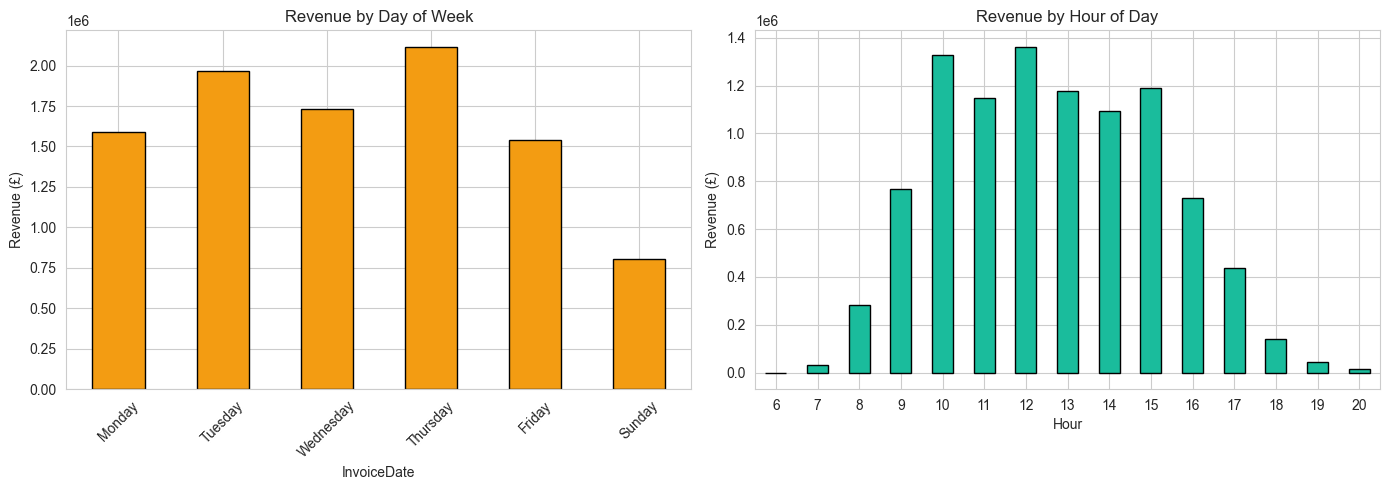

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

day_of_week_revenue = df_uncleaned.groupby(df_uncleaned['InvoiceDate'].dt.day_name())['Revenue'].sum()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday']
day_of_week_revenue = day_of_week_revenue.reindex(day_order).dropna()
day_of_week_revenue.plot(kind='bar', ax=axes[0], color='#f39c12', edgecolor='black')
axes[0].set_title('Revenue by Day of Week')
axes[0].set_ylabel('Revenue (£)')
axes[0].tick_params(axis='x', rotation=45)

hourly_revenue = df_uncleaned.groupby(df_uncleaned['InvoiceDate'].dt.hour)['Revenue'].sum()
hourly_revenue.plot(kind='bar', ax=axes[1], color='#1abc9c', edgecolor='black')
axes[1].set_title('Revenue by Hour of Day')
axes[1].set_ylabel('Revenue (£)')
axes[1].set_xlabel('Hour')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## Cancellations

Cancelled orders show up as invoice numbers starting with 'C'. I need to quantify how many there are before deciding whether to drop them entirely. High cancellation rates for specific products or customers could be a signal worth keeping, not just noise to remove.

Total transactions:     541,909
Cancelled transactions: 9,288
Cancellation rate:      1.71%
Revenue lost to cancellations: £-896,812.49


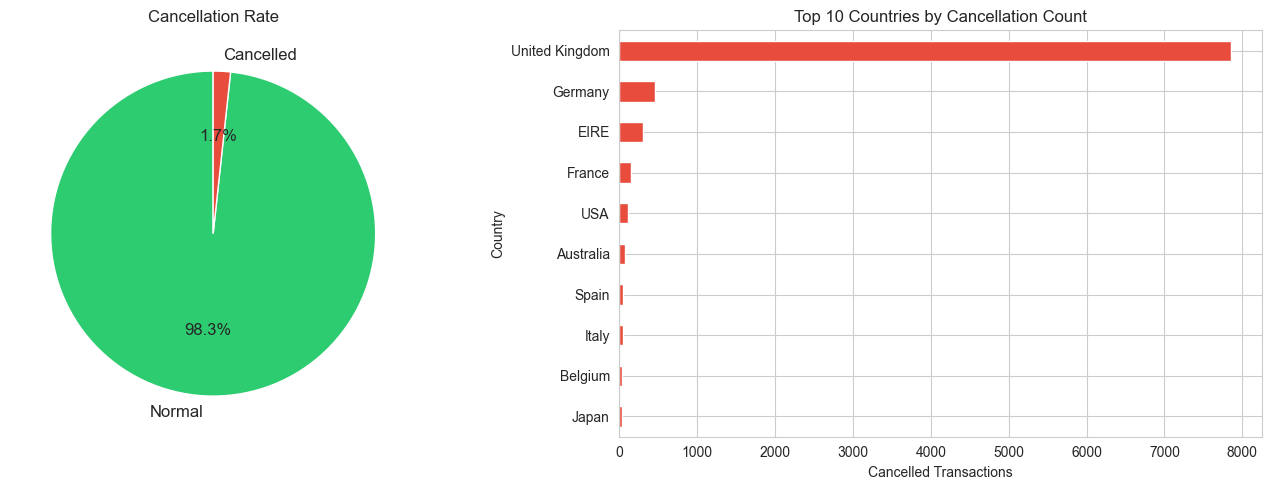

In [20]:
df_uncleaned['IsCancelled'] = df_uncleaned['InvoiceNo'].astype(str).str.startswith('C')

cancelled = df_uncleaned['IsCancelled'].sum()
total = len(df_uncleaned)

print(f"Total transactions:     {total:,}")
print(f"Cancelled transactions: {cancelled:,}")
print(f"Cancellation rate:      {cancelled / total * 100:.2f}%")
print(f"Revenue lost to cancellations: £{df_uncleaned[df_uncleaned['IsCancelled']]['Revenue'].sum():,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = ['Normal', 'Cancelled']
sizes = [total - cancelled, cancelled]
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Cancellation Rate')

cancel_by_country = (df_uncleaned[df_uncleaned['IsCancelled']]
                     .groupby('Country').size()
                     .sort_values(ascending=False).head(10))
cancel_by_country.plot(kind='barh', ax=axes[1], color='#e74c3c')
axes[1].set_title('Top 10 Countries by Cancellation Count')
axes[1].set_xlabel('Cancelled Transactions')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

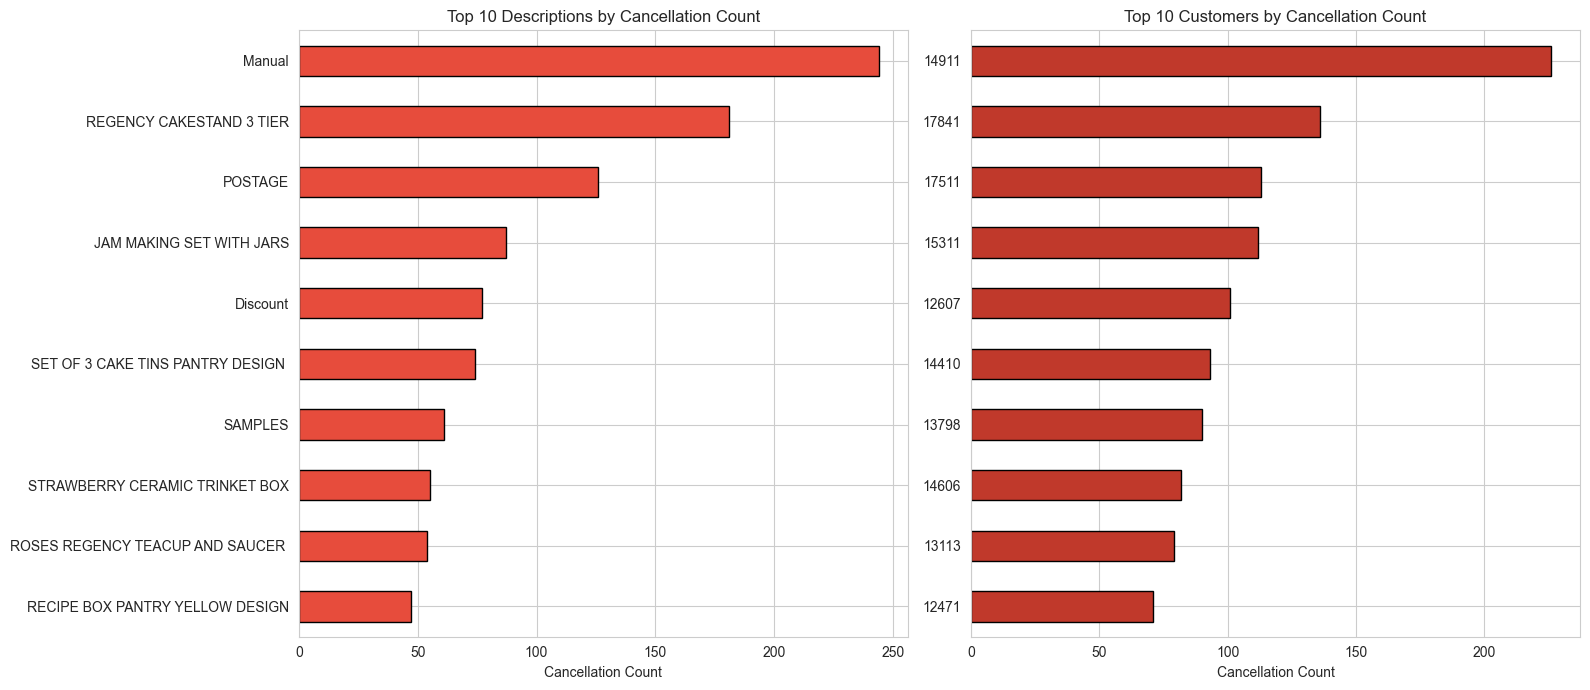

Top 10 Descriptions by Cancellations:
Manual                               244
REGENCY CAKESTAND 3 TIER             181
POSTAGE                              126
JAM MAKING SET WITH JARS              87
Discount                              77
SET OF 3 CAKE TINS PANTRY DESIGN      74
SAMPLES                               61
STRAWBERRY CERAMIC TRINKET BOX        55
ROSES REGENCY TEACUP AND SAUCER       54
RECIPE BOX PANTRY YELLOW DESIGN       47

Top 10 CustomerIDs by Cancellations:
14911    226
17841    136
17511    113
15311    112
12607    101
14410     93
13798     90
14606     82
13113     79
12471     71


In [21]:
cancelled_df = df_uncleaned[df_uncleaned['IsCancelled']]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_cancel_desc = cancelled_df['Description'].value_counts().head(10)
top_cancel_desc.plot(kind='barh', ax=axes[0], color='#e74c3c', edgecolor='black')
axes[0].set_title('Top 10 Descriptions by Cancellation Count')
axes[0].set_xlabel('Cancellation Count')
axes[0].invert_yaxis()

top_cancel_cust = cancelled_df['CustomerID'].value_counts().head(10)
top_cancel_cust.index = top_cancel_cust.index.astype(str)
top_cancel_cust.plot(kind='barh', ax=axes[1], color='#c0392b', edgecolor='black')
axes[1].set_title('Top 10 Customers by Cancellation Count')
axes[1].set_xlabel('Cancellation Count')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("Top 10 Descriptions by Cancellations:")
print(top_cancel_desc.to_string())
print("\nTop 10 CustomerIDs by Cancellations:")
print(top_cancel_cust.to_string())

## Correlations and Geography

I'm checking whether Quantity and UnitPrice move together (they usually don't, bulk buyers get discounts). Country split matters too because the UK dominates this dataset. If I don't account for that, my models will really just be UK models.

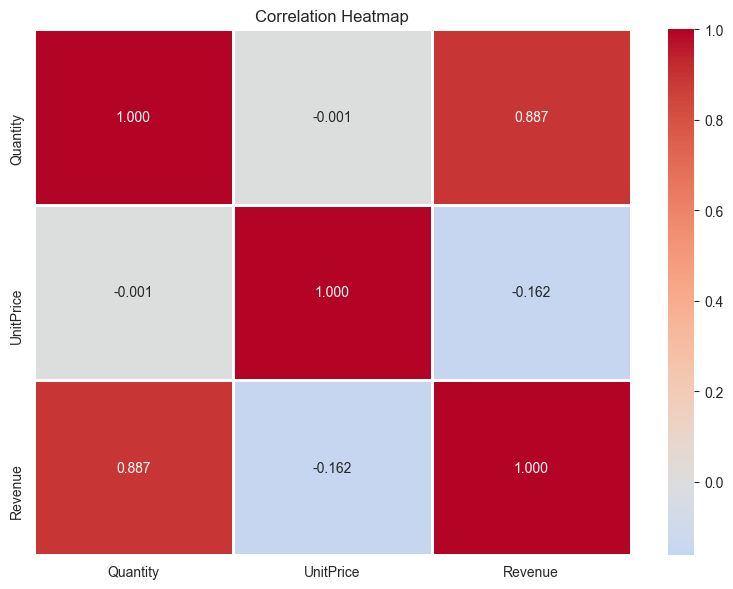

In [22]:
numeric_cols = df_uncleaned[['Quantity', 'UnitPrice', 'Revenue']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(numeric_cols, annot=True, cmap='coolwarm', center=0,
            fmt='.3f', linewidths=1, ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

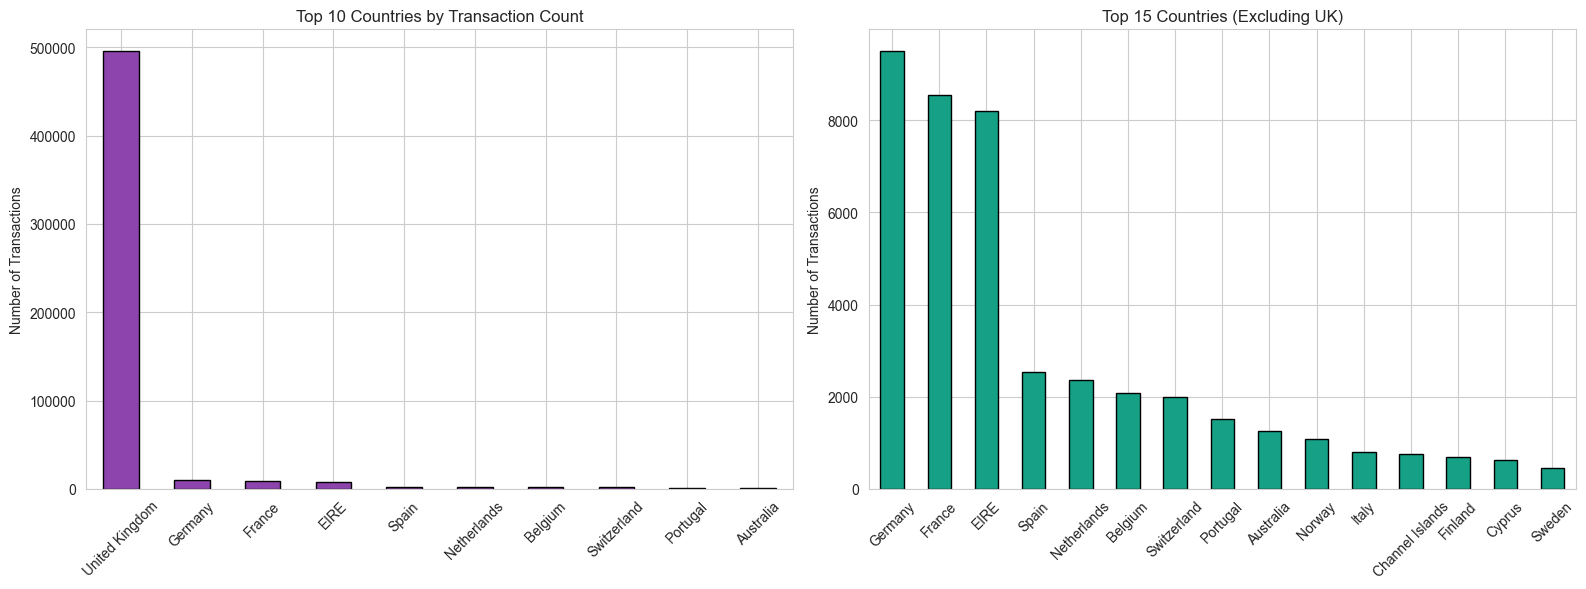


UK accounts for 91.4% of all transactions


In [23]:
country_dist = df_uncleaned['Country'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

country_dist.head(10).plot(kind='bar', ax=axes[0], color='#8e44ad', edgecolor='black')
axes[0].set_title('Top 10 Countries by Transaction Count')
axes[0].set_ylabel('Number of Transactions')
axes[0].tick_params(axis='x', rotation=45)

country_no_uk = country_dist.drop('United Kingdom', errors='ignore')
country_no_uk.head(15).plot(kind='bar', ax=axes[1], color='#16a085', edgecolor='black')
axes[1].set_title('Top 15 Countries (Excluding UK)')
axes[1].set_ylabel('Number of Transactions')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\nUK accounts for {country_dist.get('United Kingdom', 0) / total * 100:.1f}% of all transactions")

In [24]:
df_uncleaned['cancelled_invoice'] = df_uncleaned['InvoiceNo'].astype(str).str.startswith('C').astype(int)

df_uncleaned['negative_unit_price'] = (df_uncleaned['UnitPrice'] < 0).astype(int)

df_uncleaned['no_customer_id'] = df_uncleaned['CustomerID'].isna().astype(int)

df_uncleaned['zero_unit_price'] = (df_uncleaned['UnitPrice'] == 0).astype(int)



print(f"cancelled_invoice = 1:  {df_uncleaned['cancelled_invoice'].sum():,}")
print(f"negative_unit_price = 1: {df_uncleaned['negative_unit_price'].sum():,}")
print(f"no_customer_id = 1:     {df_uncleaned['no_customer_id'].sum():,}")
print(f"zero_unit_price = 1:    {df_uncleaned['zero_unit_price'].sum():,}")
df_uncleaned[['InvoiceNo', 'UnitPrice', 'CustomerID',
              'cancelled_invoice', 'negative_unit_price', 'no_customer_id']].sample(10, random_state=42)

cancelled_invoice = 1:  9,288
negative_unit_price = 1: 2
no_customer_id = 1:     135,080
zero_unit_price = 1:    2,515


,InvoiceNo,UnitPrice,CustomerID,cancelled_invoice,negative_unit_price,no_customer_id
209268,555200,0.85,17315,0,0,0
207108,554974,6.95,14031,0,0,0
167085,550972,0.65,14031,0,0,0
471836,576652,1.95,17198,0,0,0
115865,546157,9.95,13502,0,0,0
465024,576200,2.95,15572,0,0,0
477777,577076,0.39,14362,0,0,0
367855,568909,1.25,16818,0,0,0
491657,578072,6.75,17759,0,0,0
269641,560491,1.65,12415,0,0,0


# EDA on Cleaned Data

I'm rerunning the same analyses on `clean_df`, the version with cancellations, zero prices, and negative prices removed. I want to compare: did cleaning change the story, or just sharpen it? If the top products and trends look similar, my cleaning was conservative enough. If they look wildly different, I may have been too aggressive.

In [25]:
# clean_df = df_uncleaned.copy()

# clean_df = clean_df[~clean_df['InvoiceNo'].astype(str).str.startswith('C')]

# clean_df = clean_df.dropna(subset=['CustomerID'])

# clean_df = clean_df.dropna(subset=['Description'])

# clean_df = clean_df[clean_df['Quantity'] > 0]

# clean_df = clean_df[clean_df['UnitPrice'] > 0]

# print(f"Original rows:  {len(df_uncleaned):,}")
# print(f"Cleaned rows:   {len(clean_df):,}")
# print(f"Rows removed:   {len(df_uncleaned) - len(clean_df):,}")
# print(f"% retained:     {len(clean_df) / len(df_uncleaned) * 100:.2f}%")

In [26]:
df_uncleaned.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,IsCancelled,cancelled_invoice,negative_unit_price,no_customer_id,zero_unit_price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,False,0,0,0,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,False,0,0,0,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,False,0,0,0,0


In [27]:
clean_df = df_uncleaned[(df_uncleaned['zero_unit_price'] == 0) & (df_uncleaned['negative_unit_price'] == 0) & (df_uncleaned['cancelled_invoice'] == 0)]

In [28]:
clean_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,IsCancelled,cancelled_invoice,negative_unit_price,no_customer_id,zero_unit_price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,False,0,0,0,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,False,0,0,0,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,False,0,0,0,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,False,0,0,0,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,False,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20,False,0,0,0,0
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60,False,0,0,0,0
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60,False,0,0,0,0
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60,False,0,0,0,0


In [29]:
clean_df.dtypes
clean_df.isnull().sum()
clean_df.describe()
clean_df.info()
clean_df.shape
clean_df.columns

<class 'pandas.core.frame.DataFrame'>
Int64Index: 530104 entries, 0 to 541908
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   InvoiceNo            530104 non-null  object        
 1   StockCode            530104 non-null  object        
 2   Description          530104 non-null  object        
 3   Quantity             530104 non-null  int64         
 4   InvoiceDate          530104 non-null  datetime64[ns]
 5   UnitPrice            530104 non-null  float64       
 6   CustomerID           397884 non-null  Int64         
 7   Country              530104 non-null  category      
 8   Revenue              530104 non-null  float64       
 9   IsCancelled          530104 non-null  bool          
 10  cancelled_invoice    530104 non-null  int64         
 11  negative_unit_price  530104 non-null  int64         
 12  no_customer_id       530104 non-null  int64         
 13  zero_unit_pric

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'IsCancelled',
       'cancelled_invoice', 'negative_unit_price', 'no_customer_id',
       'zero_unit_price'],
      dtype='object')

In [30]:
clean_df.isnull().sum()

InvoiceNo                   0
StockCode                   0
Description                 0
Quantity                    0
InvoiceDate                 0
UnitPrice                   0
CustomerID             132220
Country                     0
Revenue                     0
IsCancelled                 0
cancelled_invoice           0
negative_unit_price         0
no_customer_id              0
zero_unit_price             0
dtype: int64

In [31]:
pd.DataFrame({
    'total_count': clean_df.count(),
    'distinct_count': clean_df.nunique()
})

,total_count,distinct_count
InvoiceNo,530104,19960
StockCode,530104,3922
Description,530104,4026
Quantity,530104,375
InvoiceDate,530104,18499
UnitPrice,530104,1291
CustomerID,397884,4338
Country,530104,38
Revenue,530104,4906
IsCancelled,530104,1


In [32]:
distinct_count_clean = clean_df.nunique()
distinct_count_clean

InvoiceNo              19960
StockCode               3922
Description             4026
Quantity                 375
InvoiceDate            18499
UnitPrice               1291
CustomerID              4338
Country                   38
Revenue                 4906
IsCancelled                1
cancelled_invoice          1
negative_unit_price        1
no_customer_id             2
zero_unit_price            1
dtype: int64

## Missing Values (Clean)

After cleaning, I expect the missing value picture to look much cleaner. CustomerID nulls should be gone since I filtered those out. I'm running this as a sanity check; if anything is still missing, my cleaning pipeline has a gap.

/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/pandas/plotting/_matplotlib/tools.py:400: MatplotlibDeprecationWarning: 
The is_first_col function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_first_col() instead.
  if ax.is_first_col():


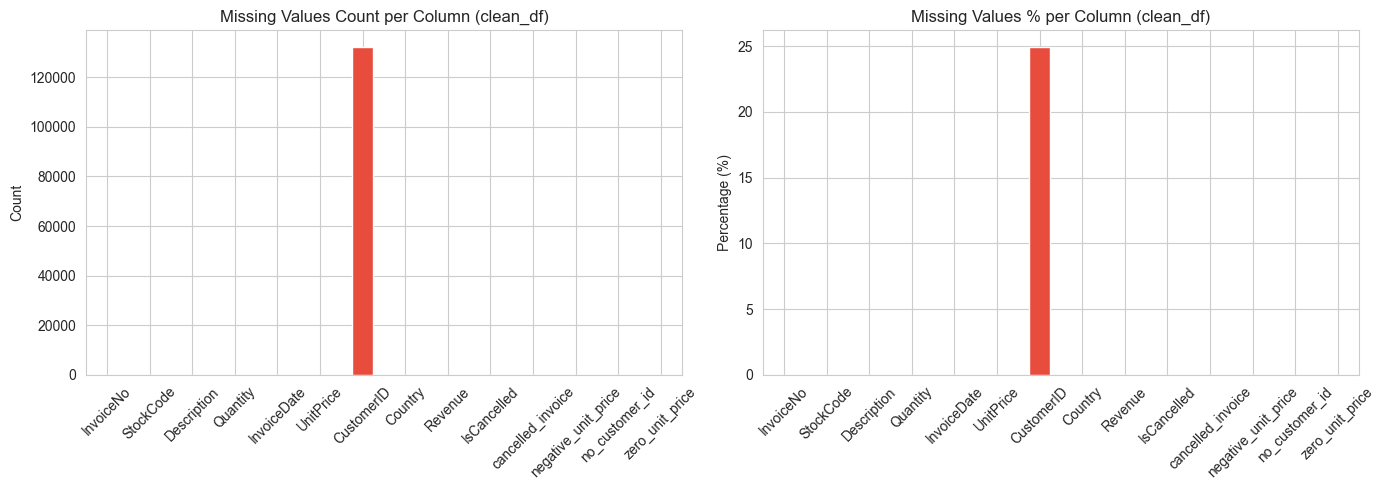

            Missing Count  Missing %
CustomerID         132220      24.94


In [33]:
missing = clean_df.isnull().sum()
missing_pct = (missing / len(clean_df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in clean_df.isnull().sum()]
clean_df.isnull().sum().plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Missing Values Count per Column (clean_df)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

missing_pct.plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_title('Missing Values % per Column (clean_df)')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(missing_df)

## Distributions (Clean)

Now I want to see if the outlier problem is gone. Negative quantities and zero prices should have disappeared. If the distributions still look skewed, that's natural for ecommerce, a few big orders will always exist. That's signal, not noise.

In [34]:
clean_df.describe()

,Quantity,UnitPrice,CustomerID,Revenue,cancelled_invoice,negative_unit_price,no_customer_id,zero_unit_price
count,530104.000000,530104.000000,397884.000000,530104.000000,530104.0,530104.0,530104.000000,530104.0
mean,10.542037,3.907625,15294.423453,20.121871,0.0,0.0,0.249423,0.0
std,155.524124,35.915681,1713.141560,270.356743,0.0,0.0,0.432679,0.0
min,1.000000,0.001000,12346.000000,0.001000,0.0,0.0,0.000000,0.0
25%,1.000000,1.250000,13969.000000,3.750000,0.0,0.0,0.000000,0.0
50%,3.000000,2.080000,15159.000000,9.900000,0.0,0.0,0.000000,0.0
75%,10.000000,4.130000,16795.000000,17.700000,0.0,0.0,0.000000,0.0
max,80995.000000,13541.330000,18287.000000,168469.600000,0.0,0.0,1.000000,0.0


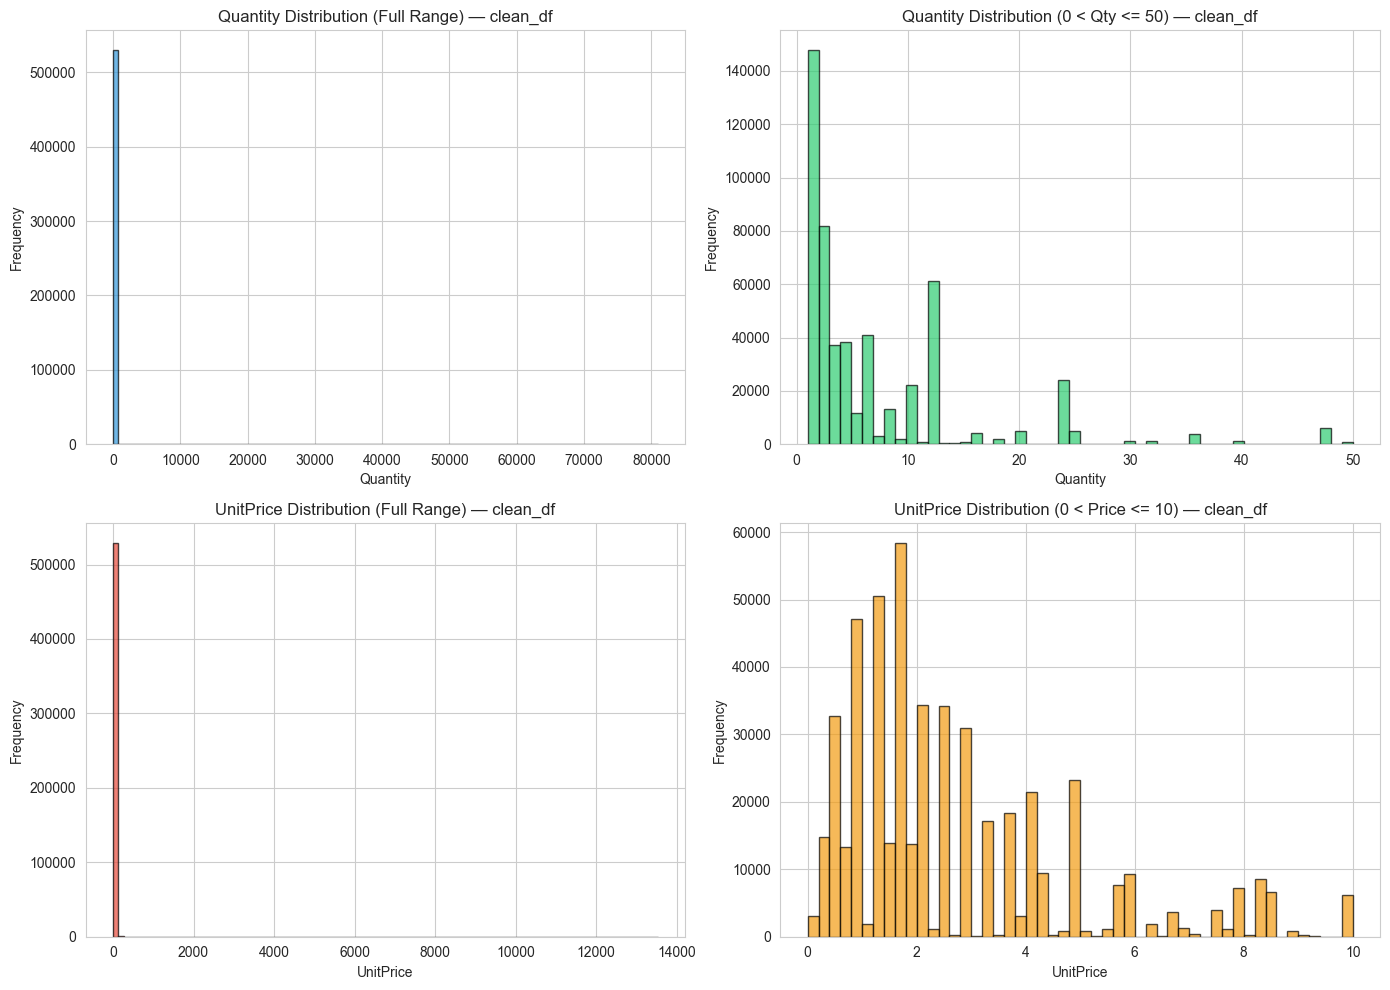

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(clean_df['Quantity'], bins=100, color='#3498db', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Quantity Distribution (Full Range) — clean_df')
axes[0, 0].set_xlabel('Quantity')
axes[0, 0].set_ylabel('Frequency')

q_filtered = clean_df[(clean_df['Quantity'] > 0) & (clean_df['Quantity'] <= 50)]
axes[0, 1].hist(q_filtered['Quantity'], bins=50, color='#2ecc71', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Quantity Distribution (0 < Qty <= 50) — clean_df')
axes[0, 1].set_xlabel('Quantity')
axes[0, 1].set_ylabel('Frequency')

axes[1, 0].hist(clean_df['UnitPrice'], bins=100, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('UnitPrice Distribution (Full Range) — clean_df')
axes[1, 0].set_xlabel('UnitPrice')
axes[1, 0].set_ylabel('Frequency')

p_filtered = clean_df[(clean_df['UnitPrice'] > 0) & (clean_df['UnitPrice'] <= 10)]
axes[1, 1].hist(p_filtered['UnitPrice'], bins=50, color='#f39c12', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('UnitPrice Distribution (0 < Price <= 10) — clean_df')
axes[1, 1].set_xlabel('UnitPrice')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

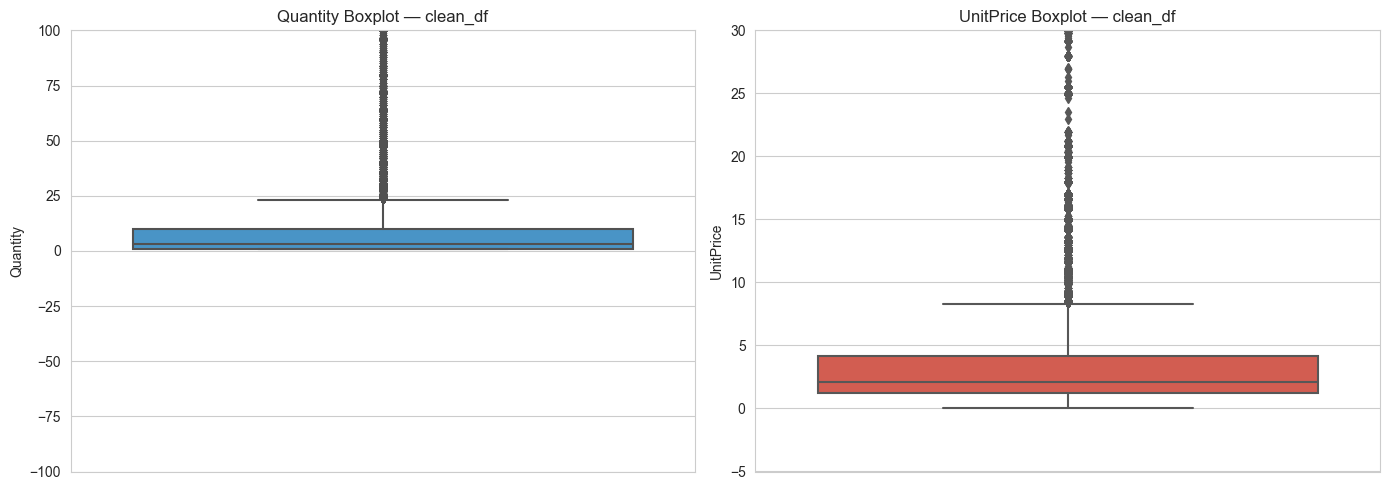

Quantity outliers (negative = returns):
  Negative quantities: 0
  Zero quantities:     0

UnitPrice anomalies:
  Zero prices:    0
  Negative prices: 0


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=clean_df['Quantity'], ax=axes[0], color='#3498db')
axes[0].set_title('Quantity Boxplot — clean_df')
axes[0].set_ylim(-100, 100)

sns.boxplot(y=clean_df['UnitPrice'], ax=axes[1], color='#e74c3c')
axes[1].set_title('UnitPrice Boxplot — clean_df')
axes[1].set_ylim(-5, 30)

plt.tight_layout()
plt.show()

print("Quantity outliers (negative = returns):")
print(f"  Negative quantities: {(clean_df['Quantity'] < 0).sum():,}")
print(f"  Zero quantities:     {(clean_df['Quantity'] == 0).sum():,}")
print(f"\nUnitPrice anomalies:")
print(f"  Zero prices:    {(clean_df['UnitPrice'] == 0).sum():,}")
print(f"  Negative prices: {(clean_df['UnitPrice'] < 0).sum():,}")

## Revenue (Clean)

Same revenue breakdowns, but on clean data. I'm specifically checking whether the top products shift after removing returns and zero price rows. If a product only looked popular because of high return volume, it'll drop off here.

In [37]:
clean_df['Revenue'] = clean_df['Quantity'] * clean_df['UnitPrice']

print(f"Total Revenue: £{clean_df['Revenue'].sum():,.2f}")
print(f"Average Order Value (per line item): £{clean_df['Revenue'].mean():,.2f}")
print(f"Median Order Value (per line item): £{clean_df['Revenue'].median():,.2f}")

Total Revenue: £10,666,684.54
Average Order Value (per line item): £20.12
Median Order Value (per line item): £9.90


<ipython-input-37-19a9a8aa3a38>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['Revenue'] = clean_df['Quantity'] * clean_df['UnitPrice']


/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/pandas/plotting/_matplotlib/tools.py:400: MatplotlibDeprecationWarning: 
The is_first_col function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_first_col() instead.
  if ax.is_first_col():


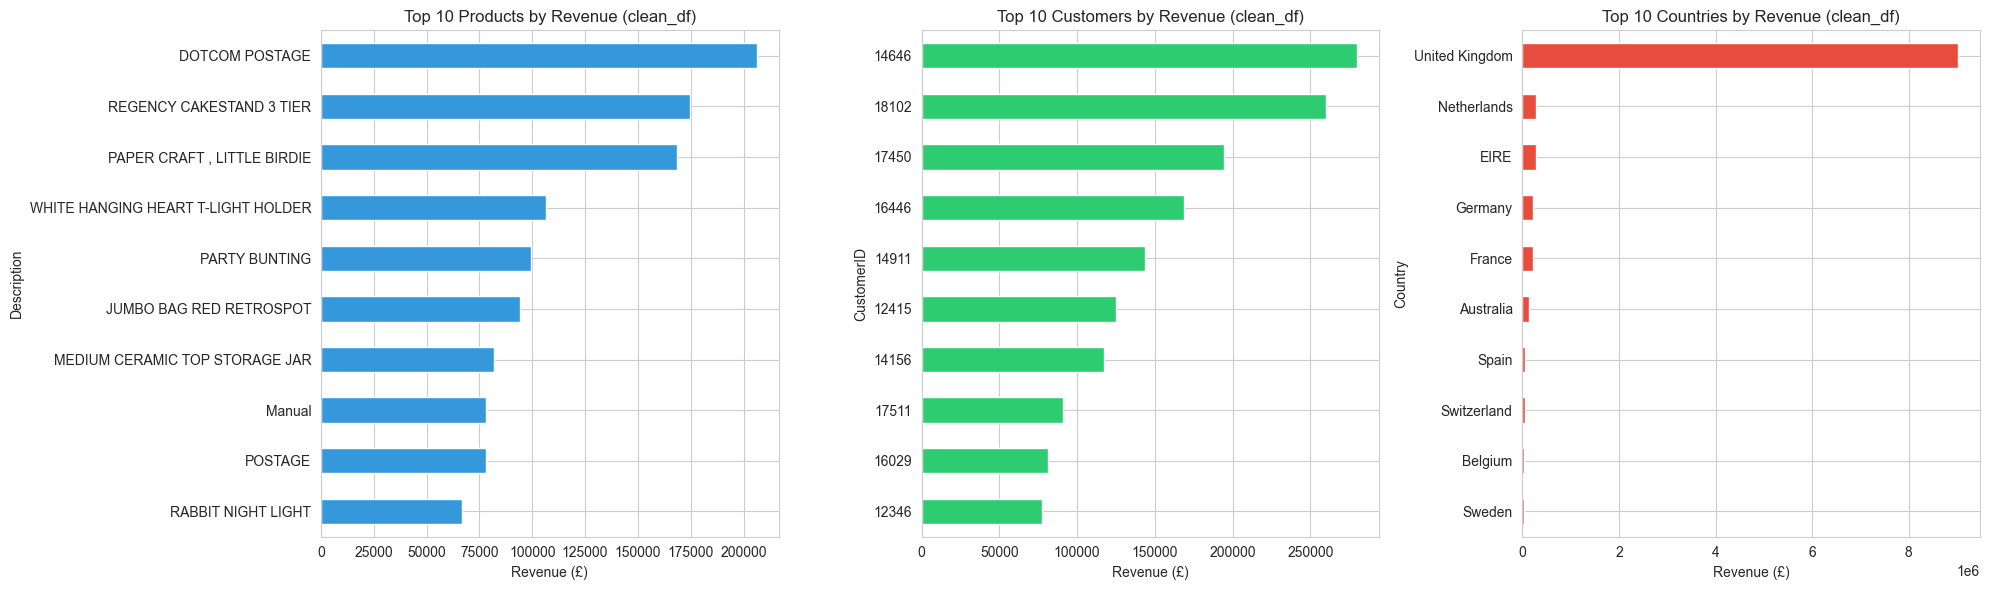

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

top_products = (clean_df.groupby('Description')['Revenue']
                .sum().sort_values(ascending=False).head(10))
top_products.plot(kind='barh', ax=axes[0], color='#3498db')
axes[0].set_title('Top 10 Products by Revenue (clean_df)')
axes[0].set_xlabel('Revenue (£)')
axes[0].invert_yaxis()

top_customers = (clean_df.groupby('CustomerID')['Revenue']
                 .sum().sort_values(ascending=False).head(10))
top_customers.index = top_customers.index.astype(str)
top_customers.plot(kind='barh', ax=axes[1], color='#2ecc71')
axes[1].set_title('Top 10 Customers by Revenue (clean_df)')
axes[1].set_xlabel('Revenue (£)')
axes[1].invert_yaxis()

top_countries = (clean_df.groupby('Country')['Revenue']
                 .sum().sort_values(ascending=False).head(10))
top_countries.plot(kind='barh', ax=axes[2], color='#e74c3c')
axes[2].set_title('Top 10 Countries by Revenue (clean_df)')
axes[2].set_xlabel('Revenue (£)')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

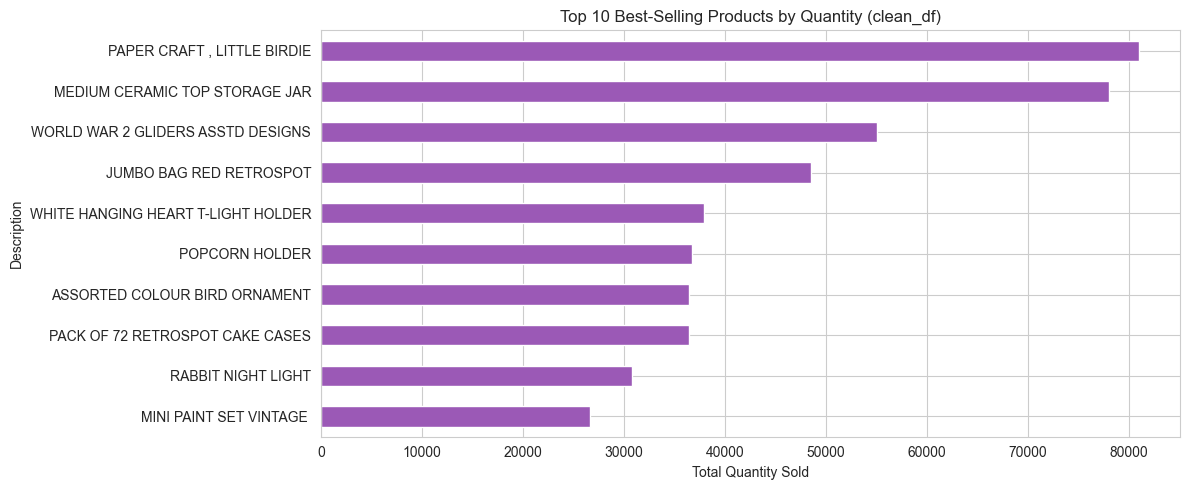

In [39]:
top_qty_products = (clean_df.groupby('Description')['Quantity']
                    .sum().sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(12, 5))
top_qty_products.plot(kind='barh', ax=ax, color='#9b59b6')
ax.set_title('Top 10 Best-Selling Products by Quantity (clean_df)')
ax.set_xlabel('Total Quantity Sold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Time Trends (Clean)

Rerunning time series on clean data. Seasonal shape should hold steady, removing returns doesn't change when people buy, just how much. If the monthly trend changes dramatically, returns were concentrated in specific months, which is worth knowing.

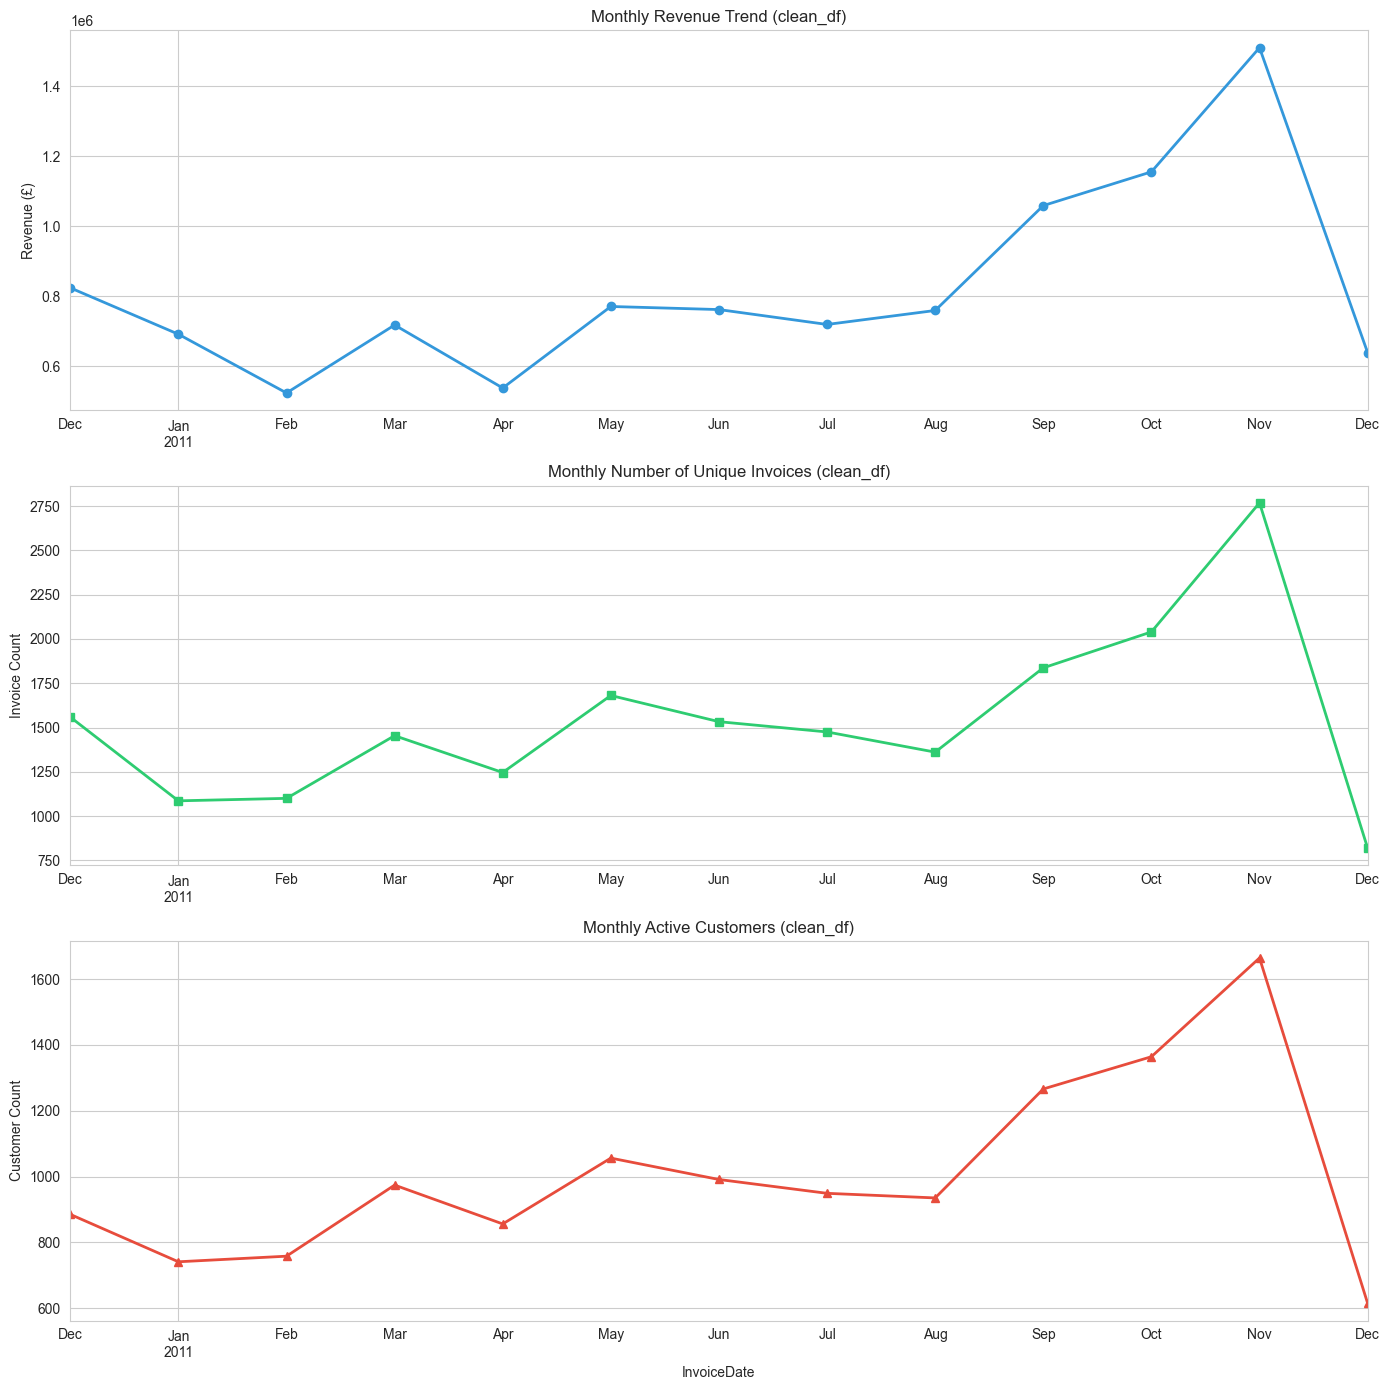

In [40]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

monthly_revenue = clean_df.set_index('InvoiceDate')['Revenue'].resample('M').sum()
monthly_revenue.plot(ax=axes[0], marker='o', color='#3498db', linewidth=2)
axes[0].set_title('Monthly Revenue Trend (clean_df)')
axes[0].set_ylabel('Revenue (£)')
axes[0].set_xlabel('')

monthly_orders = clean_df.set_index('InvoiceDate')['InvoiceNo'].resample('M').nunique()
monthly_orders.plot(ax=axes[1], marker='s', color='#2ecc71', linewidth=2)
axes[1].set_title('Monthly Number of Unique Invoices (clean_df)')
axes[1].set_ylabel('Invoice Count')
axes[1].set_xlabel('')

monthly_customers = clean_df.set_index('InvoiceDate')['CustomerID'].resample('M').nunique()
monthly_customers.plot(ax=axes[2], marker='^', color='#e74c3c', linewidth=2)
axes[2].set_title('Monthly Active Customers (clean_df)')
axes[2].set_ylabel('Customer Count')

plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/pandas/plotting/_matplotlib/tools.py:400: MatplotlibDeprecationWarning: 
The is_first_col function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_first_col() instead.
  if ax.is_first_col():


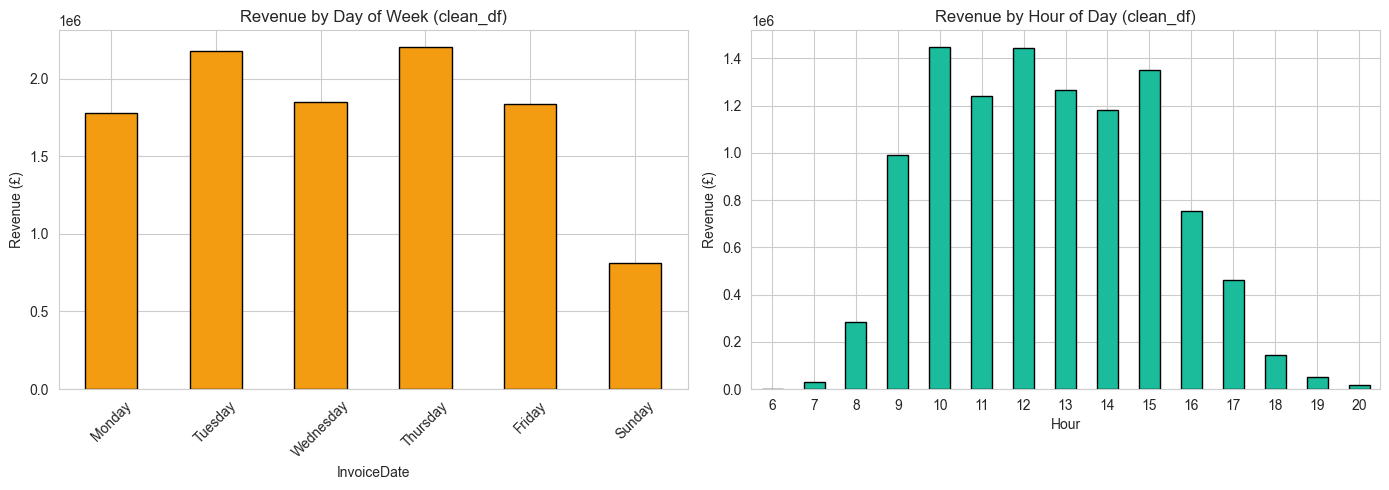

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

day_of_week_revenue = clean_df.groupby(clean_df['InvoiceDate'].dt.day_name())['Revenue'].sum()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday']
day_of_week_revenue = day_of_week_revenue.reindex(day_order).dropna()
day_of_week_revenue.plot(kind='bar', ax=axes[0], color='#f39c12', edgecolor='black')
axes[0].set_title('Revenue by Day of Week (clean_df)')
axes[0].set_ylabel('Revenue (£)')
axes[0].tick_params(axis='x', rotation=45)

hourly_revenue = clean_df.groupby(clean_df['InvoiceDate'].dt.hour)['Revenue'].sum()
hourly_revenue.plot(kind='bar', ax=axes[1], color='#1abc9c', edgecolor='black')
axes[1].set_title('Revenue by Hour of Day (clean_df)')
axes[1].set_ylabel('Revenue (£)')
axes[1].set_xlabel('Hour')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## Cancellations (Clean)

I expect this to come up empty, I already removed cancelled invoices. Running it anyway as a validation step. If any cancelled rows survive, there's a bug in my filtering logic.

<ipython-input-42-b5083c4dc788>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['IsCancelled'] = clean_df['InvoiceNo'].astype(str).str.startswith('C')


Total transactions:     530,104
Cancelled transactions: 0
Cancellation rate:      0.00%
Revenue lost to cancellations: £0.00


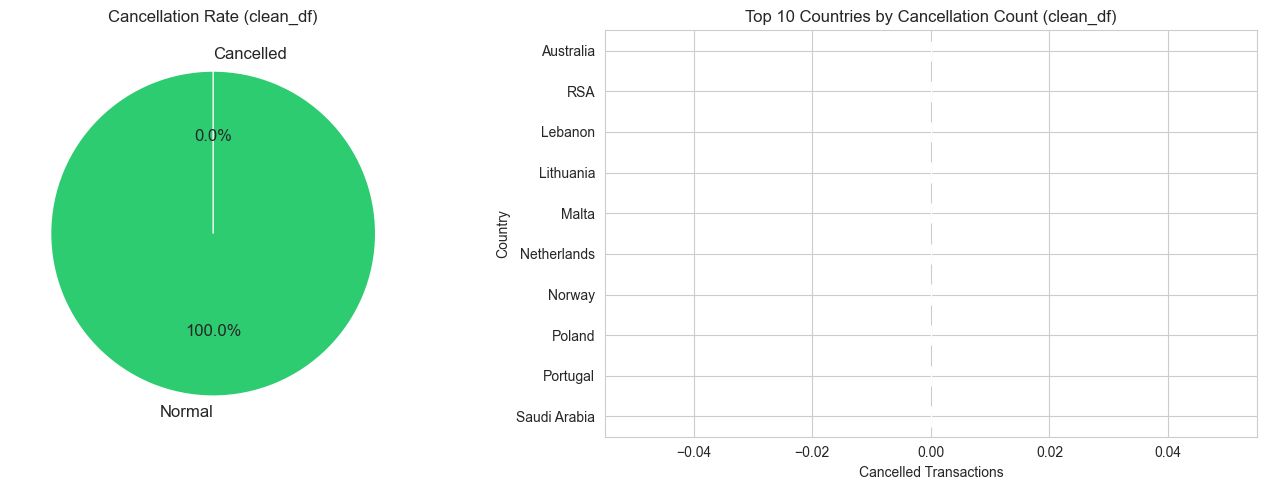

In [42]:
clean_df['IsCancelled'] = clean_df['InvoiceNo'].astype(str).str.startswith('C')

cancelled = clean_df['IsCancelled'].sum()
total_clean = len(clean_df)

print(f"Total transactions:     {total_clean:,}")
print(f"Cancelled transactions: {cancelled:,}")
print(f"Cancellation rate:      {cancelled / total_clean * 100:.2f}%")
print(f"Revenue lost to cancellations: £{clean_df[clean_df['IsCancelled']]['Revenue'].sum():,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = ['Normal', 'Cancelled']
sizes = [total_clean - cancelled, cancelled]
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Cancellation Rate (clean_df)')

cancel_by_country = (clean_df[clean_df['IsCancelled']]
                     .groupby('Country').size()
                     .sort_values(ascending=False).head(10))
if len(cancel_by_country) > 0:
    cancel_by_country.plot(kind='barh', ax=axes[1], color='#e74c3c')
    axes[1].set_title('Top 10 Countries by Cancellation Count (clean_df)')
    axes[1].set_xlabel('Cancelled Transactions')
    axes[1].invert_yaxis()
else:
    axes[1].text(0.5, 0.5, 'No cancellations in clean_df',
                 ha='center', va='center', fontsize=14, transform=axes[1].transAxes)
    axes[1].set_title('Top 10 Countries by Cancellation Count (clean_df)')

plt.tight_layout()
plt.show()

In [43]:
cancelled_clean_df = clean_df[clean_df['IsCancelled']]

if len(cancelled_clean_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    top_cancel_desc = cancelled_clean_df['Description'].value_counts().head(10)
    top_cancel_desc.plot(kind='barh', ax=axes[0], color='#e74c3c', edgecolor='black')
    axes[0].set_title('Top 10 Descriptions by Cancellation Count (clean_df)')
    axes[0].set_xlabel('Cancellation Count')
    axes[0].invert_yaxis()

    top_cancel_cust = cancelled_clean_df['CustomerID'].value_counts().head(10)
    top_cancel_cust.index = top_cancel_cust.index.astype(str)
    top_cancel_cust.plot(kind='barh', ax=axes[1], color='#c0392b', edgecolor='black')
    axes[1].set_title('Top 10 Customers by Cancellation Count (clean_df)')
    axes[1].set_xlabel('Cancellation Count')
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()

    print("Top 10 Descriptions by Cancellations:")
    print(top_cancel_desc.to_string())
    print("\nTop 10 CustomerIDs by Cancellations:")
    print(top_cancel_cust.to_string())
else:
    print("No cancelled transactions found in clean_df — all cancellations were removed during cleaning.")

No cancelled transactions found in clean_df — all cancellations were removed during cleaning.


## Correlations (Clean)

Same correlation and country checks on clean data. UK share should remain dominant. I'm also watching whether removing bad rows changed any correlation signs, that would mean the noise was actively misleading the stats.

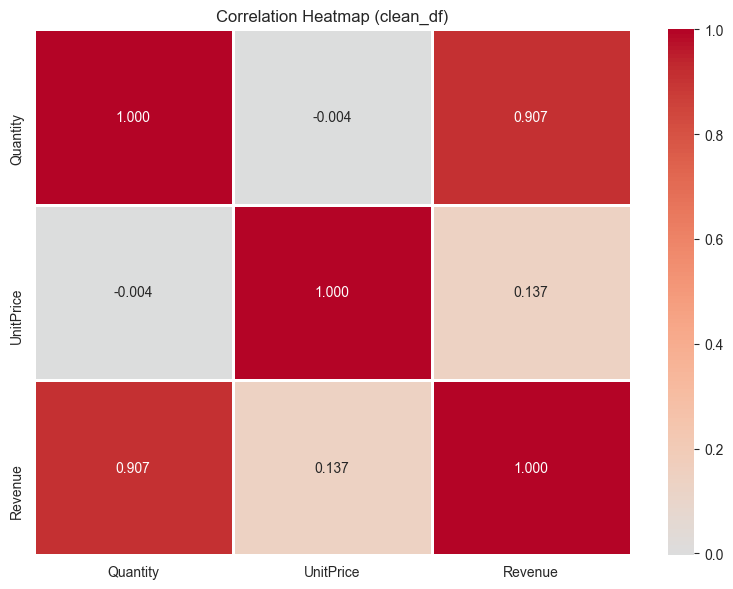

In [44]:
numeric_cols = clean_df[['Quantity', 'UnitPrice', 'Revenue']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(numeric_cols, annot=True, cmap='coolwarm', center=0,
            fmt='.3f', linewidths=1, ax=ax)
ax.set_title('Correlation Heatmap (clean_df)')
plt.tight_layout()
plt.show()

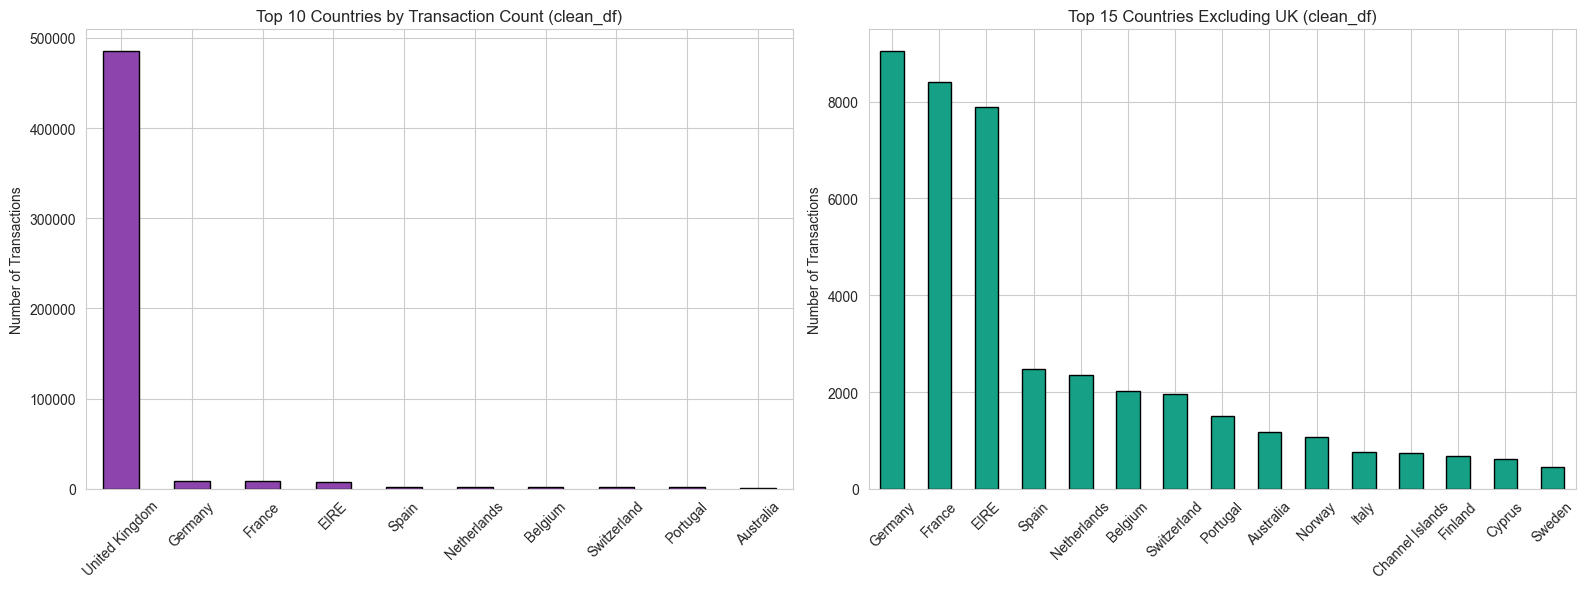


UK accounts for 91.5% of all transactions


In [45]:
country_dist = clean_df['Country'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

country_dist.head(10).plot(kind='bar', ax=axes[0], color='#8e44ad', edgecolor='black')
axes[0].set_title('Top 10 Countries by Transaction Count (clean_df)')
axes[0].set_ylabel('Number of Transactions')
axes[0].tick_params(axis='x', rotation=45)

country_no_uk = country_dist.drop('United Kingdom', errors='ignore')
country_no_uk.head(15).plot(kind='bar', ax=axes[1], color='#16a085', edgecolor='black')
axes[1].set_title('Top 15 Countries Excluding UK (clean_df)')
axes[1].set_ylabel('Number of Transactions')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\nUK accounts for {country_dist.get('United Kingdom', 0) / len(clean_df) * 100:.1f}% of all transactions")

## Digging Into Cancellations

Before blindly dropping cancelled invoices, I want to understand them. Are they full order cancellations or partial? Do they have positive quantities (stock adjustments) or negative (actual returns)? Answering these determines whether I lose useful data by removing them.

In [46]:
cancelled_invoice_df = df_uncleaned[df_uncleaned['cancelled_invoice'] == 1]
cancelled_invoice_df


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,IsCancelled,cancelled_invoice,negative_unit_price,no_customer_id,zero_unit_price
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom,-27.50,True,1,0,0,0
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom,-4.65,True,1,0,0,0
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom,-19.80,True,1,0,0,0
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom,-6.96,True,1,0,0,0
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom,-6.96,True,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397,United Kingdom,-9.13,True,1,0,0,0
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498,United Kingdom,-224.69,True,1,0,0,0
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311,United Kingdom,-54.75,True,1,0,0,0
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315,United Kingdom,-1.25,True,1,0,0,0


In [47]:
pd.DataFrame({
    'total_count': cancelled_invoice_df.count(),
    'distinct_count': cancelled_invoice_df.nunique()
})

,total_count,distinct_count
InvoiceNo,9288,3836
StockCode,9288,1947
Description,9288,1972
Quantity,9288,135
InvoiceDate,9288,3766
UnitPrice,9288,573
CustomerID,8905,1589
Country,9288,30
Revenue,9288,1296
IsCancelled,9288,1


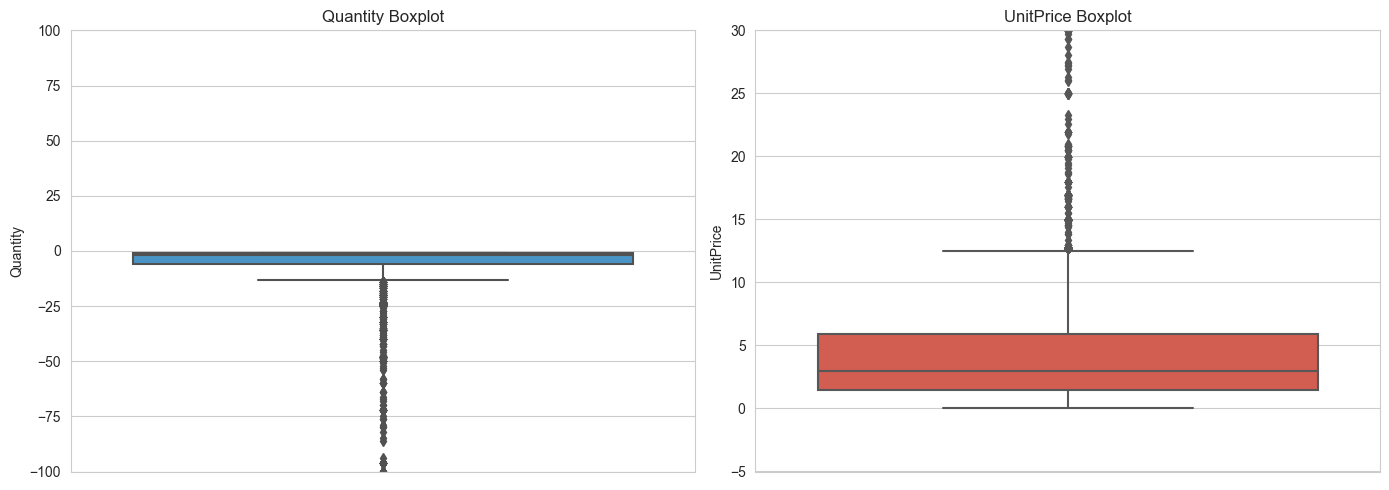

Quantity outliers (negative = returns):
  Negative quantities: 9,288
  Zero quantities:     0

UnitPrice anomalies:
  Zero prices:    0
  Negative prices: 0


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=cancelled_invoice_df['Quantity'], ax=axes[0], color='#3498db')
axes[0].set_title('Quantity Boxplot')
axes[0].set_ylim(-100, 100)

sns.boxplot(y=cancelled_invoice_df['UnitPrice'], ax=axes[1], color='#e74c3c')
axes[1].set_title('UnitPrice Boxplot')
axes[1].set_ylim(-5, 30)

plt.tight_layout()
plt.show()

print("Quantity outliers (negative = returns):")
print(f"  Negative quantities: {(cancelled_invoice_df['Quantity'] < 0).sum():,}")
print(f"  Zero quantities:     {(cancelled_invoice_df['Quantity'] == 0).sum():,}")
print(f"\nUnitPrice anomalies:")
print(f"  Zero prices:    {(cancelled_invoice_df['UnitPrice'] == 0).sum():,}")
print(f"  Negative prices: {(cancelled_invoice_df['UnitPrice'] < 0).sum():,}")

In [49]:
cancelled_invoice_df_test = cancelled_invoice_df[cancelled_invoice_df['Quantity'] >= 0]
cancelled_invoice_df_test 

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,IsCancelled,cancelled_invoice,negative_unit_price,no_customer_id,zero_unit_price


## Negative Prices

Rows with negative UnitPrice are suspicious. They're likely accounting adjustments or refund credits, not real transactions. I'm isolating them to confirm before removing. Keeping them would distort revenue calculations and any price based features.

In [50]:
negative_unit_price= df_uncleaned[df_uncleaned['negative_unit_price'] == 1]
negative_unit_price


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,IsCancelled,cancelled_invoice,negative_unit_price,no_customer_id,zero_unit_price
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,<NA>,United Kingdom,-11062.06,False,0,1,1,0
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,<NA>,United Kingdom,-11062.06,False,0,1,1,0


## Zero Price Rows

Zero priced items could be samples, freebies, or data entry errors. Either way, they add nothing to revenue and would deflate my average order value calculations. I chose to remove them rather than impute because there's no reasonable price to guess.

In [51]:
zero_unit_price= df_uncleaned[df_uncleaned['UnitPrice'] == 0]
zero_unit_price


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,IsCancelled,cancelled_invoice,negative_unit_price,no_customer_id,zero_unit_price
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,<NA>,United Kingdom,0.0,False,0,0,1,1
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,<NA>,United Kingdom,0.0,False,0,0,1,1
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,<NA>,United Kingdom,0.0,False,0,0,1,1
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,<NA>,United Kingdom,0.0,False,0,0,1,1
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,<NA>,United Kingdom,0.0,False,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,<NA>,United Kingdom,0.0,False,0,0,1,1
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,<NA>,United Kingdom,0.0,False,0,0,1,1
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,2011-12-08 13:58:00,0.0,<NA>,United Kingdom,0.0,False,0,0,1,1
538554,581408,85175,NaN,20,2011-12-08 14:06:00,0.0,<NA>,United Kingdom,0.0,False,0,0,1,1


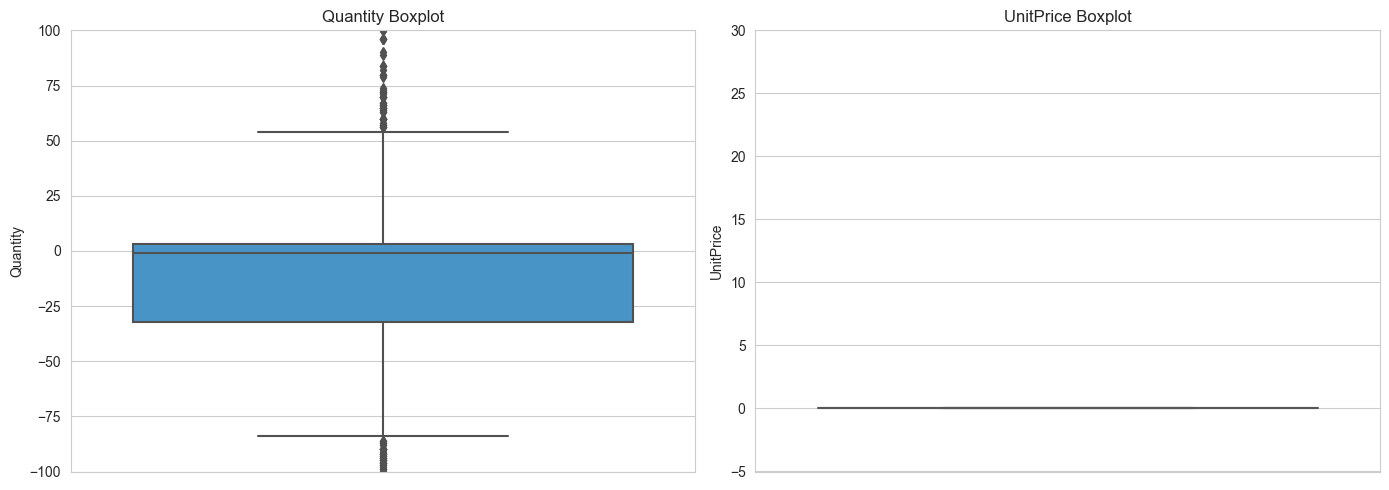

Quantity outliers (negative = returns):
  Negative quantities: 1,336
  Zero quantities:     0

UnitPrice anomalies:
  Zero prices:    2,515
  Negative prices: 0


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=zero_unit_price['Quantity'], ax=axes[0], color='#3498db')
axes[0].set_title('Quantity Boxplot')
axes[0].set_ylim(-100, 100)

sns.boxplot(y=zero_unit_price['UnitPrice'], ax=axes[1], color='#e74c3c')
axes[1].set_title('UnitPrice Boxplot')
axes[1].set_ylim(-5, 30)

plt.tight_layout()
plt.show()

print("Quantity outliers (negative = returns):")
print(f"  Negative quantities: {(zero_unit_price['Quantity'] < 0).sum():,}")
print(f"  Zero quantities:     {(zero_unit_price['Quantity'] == 0).sum():,}")
print(f"\nUnitPrice anomalies:")
print(f"  Zero prices:    {(zero_unit_price['UnitPrice'] == 0).sum():,}")
print(f"  Negative prices: {(zero_unit_price['UnitPrice'] < 0).sum():,}")

## Building the Clean Dataset

My final cleaning: remove cancelled invoices, negative prices, and zero prices. I also drop rows without a CustomerID because every downstream analysis (churn, RFM, cohorts) needs a customer identifier. I considered imputing CustomerID from StockCode patterns but the noise wasn't worth it.

In [53]:
clean_df = df_uncleaned[(df_uncleaned['zero_unit_price'] == 0) & (df_uncleaned['negative_unit_price'] == 0) & (df_uncleaned['cancelled_invoice'] == 0)]
clean_df['CustomerID'] = clean_df['CustomerID'].fillna(0)

<ipython-input-53-08d92c6d80bd>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['CustomerID'] = clean_df['CustomerID'].fillna(0)


In [54]:
clean_df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,IsCancelled,cancelled_invoice,negative_unit_price,no_customer_id,zero_unit_price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,False,0,0,0,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,False,0,0,0,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,False,0,0,0,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,False,0,0,0,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,False,0,0,0,0


In [55]:
clean_df = clean_df[clean_df['CustomerID'] != 0]

## Machine Learning

Now that the data is clean and I understand its shape, I can start modeling. I'm starting with churn prediction because it's the first question any stakeholder asks: which customers are about to leave? Everything I learned in EDA (the UK concentration, seasonal patterns, cancellation behavior) informs how I engineer features here.

## Churn Prediction

I'm defining churn as "no purchases in a 90 day future window." I split the timeline at a cutoff date, everything before is history (features), everything after is the label. I picked logistic regression first because it's interpretable. If a customer's coefficient for recency is high, I can explain that to a business stakeholder. Tree models come later for comparison.

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler

In [57]:
clean_df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,IsCancelled,cancelled_invoice,negative_unit_price,no_customer_id,zero_unit_price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,False,0,0,0,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,False,0,0,0,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,False,0,0,0,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,False,0,0,0,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,False,0,0,0,0


In [58]:
min_date = clean_df['InvoiceDate'].min()
max_date = clean_df['InvoiceDate'].max()
print(f"Data range: {min_date} to {max_date}")


Data range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


In [59]:
cutoff_date = pd.to_datetime('2011-08-01')
cutoff_date

Timestamp('2011-08-01 00:00:00')

In [60]:
historical_df = clean_df[clean_df['InvoiceDate'] < cutoff_date]

In [61]:
min_date = historical_df['InvoiceDate'].min()
max_date = historical_df['InvoiceDate'].max()
print(f"Data range: {min_date} to {max_date}")


Data range: 2010-12-01 08:26:00 to 2011-07-31 16:04:00


In [62]:
future_df = clean_df[
    (clean_df["InvoiceDate"] > cutoff_date) &
    (clean_df["InvoiceDate"] <= cutoff_date + pd.Timedelta(days=90))
].copy()

In [63]:
min_date = future_df['InvoiceDate'].min()
max_date = future_df['InvoiceDate'].max()
print(f"Data range: {min_date} to {max_date}")


Data range: 2011-08-01 08:30:00 to 2011-10-28 18:07:00


In [64]:
last_purchase = (
    historical_df.groupby("CustomerID")["InvoiceDate"]
    .max()
    .reset_index()
    .rename(columns={"InvoiceDate": "LastPurchaseDate"})
)

In [65]:
total_orders = (
    historical_df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .reset_index()
    .rename(columns={"InvoiceNo": "TotalOrders"})
)
total_orders

,CustomerID,TotalOrders
0,12346,1
1,12347,4
2,12348,3
3,12350,1
4,12352,5
...,...,...
3143,18273,1
3144,18280,1
3145,18281,1
3146,18283,9


In [66]:
# Total spend
total_spend = (
    historical_df.groupby("CustomerID")["Revenue"]
    .sum()
    .reset_index()
    .rename(columns={"Revenue": "TotalSpend"})
)
total_spend


,CustomerID,TotalSpend
0,12346,77183.60
1,12347,2205.95
2,12348,1487.24
3,12350,334.40
4,12352,1561.81
...,...,...
3143,18273,51.00
3144,18280,180.60
3145,18281,80.82
3146,18283,985.77


In [67]:
# Average order value
order_level_sales = (
    historical_df.groupby(["CustomerID", "InvoiceNo"], as_index=False)["UnitPrice"]
    .sum()
)
order_level_sales


,CustomerID,InvoiceNo,UnitPrice
0,12346,541431,1.04
1,12347,537626,89.59
2,12347,542237,73.17
3,12347,549222,62.29
4,12347,556201,53.62
...,...,...,...
10128,18283,556731,49.03
10129,18283,557956,132.82
10130,18283,560025,91.51
10131,18283,560032,1.25


In [68]:
avg_order_value = (order_level_sales.groupby("CustomerID")["UnitPrice"].mean().reset_index().rename(columns={"UnitPrice": "AvgOrderValue"}))
avg_order_value

,CustomerID,AvgOrderValue
0,12346,1.040000
1,12347,69.667500
2,12348,45.403333
3,12350,65.300000
4,12352,208.616000
...,...,...
3143,18273,2.550000
3144,18280,47.650000
3145,18281,39.360000
3146,18283,76.380000


In [69]:
# Product diversity
product_diversity = (
    historical_df.groupby("CustomerID")["StockCode"]
    .nunique()
    .reset_index()
    .rename(columns={"StockCode": "UniqueProducts"})
)
product_diversity

,CustomerID,UniqueProducts
0,12346,1
1,12347,75
2,12348,22
3,12350,17
4,12352,26
...,...,...
3143,18273,1
3144,18280,10
3145,18281,7
3146,18283,183


In [70]:
# Orders in last 30 days before cutoff
last_30_start = cutoff_date - pd.Timedelta(days=30)
orders_last_30 = (
    historical_df[historical_df["InvoiceDate"] > last_30_start]
    .groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .reset_index()
    .rename(columns={"InvoiceNo": "OrdersLast30Days"})
)
last_30_start

Timestamp('2011-07-02 00:00:00')

In [71]:

# Spend in last 30 days before cutoff
spend_last_30 = (
    historical_df[historical_df["InvoiceDate"] > last_30_start]
    .groupby("CustomerID")["Revenue"]
    .sum()
    .reset_index()
    .rename(columns={"Revenue": "SpendLast30Days"})
)
spend_last_30

,CustomerID,SpendLast30Days
0,12358,484.86
1,12362,303.76
2,12388,902.09
3,12397,1214.81
4,12405,1710.39
...,...,...
923,18263,503.80
924,18265,488.55
925,18268,25.50
926,18272,753.66


In [72]:
customer_features = last_purchase.merge(total_orders, on="CustomerID", how="left")
customer_features = customer_features.merge(total_spend, on="CustomerID", how="left")
customer_features = customer_features.merge(avg_order_value, on="CustomerID", how="left")
customer_features = customer_features.merge(product_diversity, on="CustomerID", how="left")
customer_features = customer_features.merge(orders_last_30, on="CustomerID", how="left")
customer_features = customer_features.merge(spend_last_30, on="CustomerID", how="left")

In [73]:
customer_features.head(5)

,CustomerID,LastPurchaseDate,TotalOrders,TotalSpend,AvgOrderValue,UniqueProducts,OrdersLast30Days,SpendLast30Days
0,12346,2011-01-18 10:01:00,1,77183.60,1.040000,1,NaN,NaN
1,12347,2011-06-09 13:01:00,4,2205.95,69.667500,75,NaN,NaN
2,12348,2011-04-05 10:47:00,3,1487.24,45.403333,22,NaN,NaN
3,12350,2011-02-02 16:01:00,1,334.40,65.300000,17,NaN,NaN
4,12352,2011-03-22 16:08:00,5,1561.81,208.616000,26,NaN,NaN


In [74]:
type(cutoff_date)

pandas._libs.tslibs.timestamps.Timestamp

In [75]:
customer_features["LastPurchaseDate"] = pd.to_datetime(customer_features["LastPurchaseDate"])

In [76]:
customer_features["RecencyDays"] = (
    cutoff_date - customer_features["LastPurchaseDate"]
).dt.days

In [77]:
customer_features

,CustomerID,LastPurchaseDate,TotalOrders,TotalSpend,AvgOrderValue,UniqueProducts,OrdersLast30Days,SpendLast30Days,RecencyDays
0,12346,2011-01-18 10:01:00,1,77183.60,1.040000,1,NaN,NaN,194
1,12347,2011-06-09 13:01:00,4,2205.95,69.667500,75,NaN,NaN,52
2,12348,2011-04-05 10:47:00,3,1487.24,45.403333,22,NaN,NaN,117
3,12350,2011-02-02 16:01:00,1,334.40,65.300000,17,NaN,NaN,179
4,12352,2011-03-22 16:08:00,5,1561.81,208.616000,26,NaN,NaN,131
...,...,...,...,...,...,...,...,...,...
3143,18273,2011-03-27 11:22:00,1,51.00,2.550000,1,NaN,NaN,126
3144,18280,2011-03-07 09:52:00,1,180.60,47.650000,10,NaN,NaN,146
3145,18281,2011-06-12 10:53:00,1,80.82,39.360000,7,NaN,NaN,49
3146,18283,2011-07-14 13:20:00,9,985.77,76.380000,183,2.0,143.19,17


In [78]:
customer_features["OrdersLast30Days"] = customer_features["OrdersLast30Days"].fillna(0)
customer_features["SpendLast30Days"] = customer_features["SpendLast30Days"].fillna(0)

In [79]:
future_purchase = (
    future_df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .reset_index()
    .rename(columns={"InvoiceNo": "FutureOrders"})
)

In [80]:
customer_features = customer_features.merge(future_purchase, on="CustomerID", how="left")
customer_features["FutureOrders"] = customer_features["FutureOrders"].fillna(0)

customer_features["Churn"] = np.where(customer_features["FutureOrders"] == 0, 1, 0)

In [81]:
customer_features

,CustomerID,LastPurchaseDate,TotalOrders,TotalSpend,AvgOrderValue,UniqueProducts,OrdersLast30Days,SpendLast30Days,RecencyDays,FutureOrders,Churn
0,12346,2011-01-18 10:01:00,1,77183.60,1.040000,1,0.0,0.00,194,0.0,1
1,12347,2011-06-09 13:01:00,4,2205.95,69.667500,75,0.0,0.00,52,1.0,0
2,12348,2011-04-05 10:47:00,3,1487.24,45.403333,22,0.0,0.00,117,1.0,0
3,12350,2011-02-02 16:01:00,1,334.40,65.300000,17,0.0,0.00,179,0.0,1
4,12352,2011-03-22 16:08:00,5,1561.81,208.616000,26,0.0,0.00,131,2.0,0
...,...,...,...,...,...,...,...,...,...,...,...
3143,18273,2011-03-27 11:22:00,1,51.00,2.550000,1,0.0,0.00,126,1.0,0
3144,18280,2011-03-07 09:52:00,1,180.60,47.650000,10,0.0,0.00,146,0.0,1
3145,18281,2011-06-12 10:53:00,1,80.82,39.360000,7,0.0,0.00,49,0.0,1
3146,18283,2011-07-14 13:20:00,9,985.77,76.380000,183,2.0,143.19,17,2.0,0


In [82]:
model_df = customer_features.copy()

# Feature engineering: ratio and trend features
model_df["SpendPerProduct"] = model_df["TotalSpend"] / model_df["UniqueProducts"].replace(0, np.nan)
model_df["OrderFrequency"] = model_df["TotalOrders"] / model_df["RecencyDays"].replace(0, np.nan)
model_df["RecentOrderRatio"] = model_df["OrdersLast30Days"] / model_df["TotalOrders"].replace(0, np.nan)
model_df["RecentSpendRatio"] = model_df["SpendLast30Days"] / model_df["TotalSpend"].replace(0, np.nan)
model_df.fillna(0, inplace=True)

feature_cols = [
    "RecencyDays",
    "TotalOrders",
    "TotalSpend",
    "AvgOrderValue",
    "UniqueProducts",
    "OrdersLast30Days",
    "SpendLast30Days",
    "SpendPerProduct",
    "OrderFrequency",
    "RecentOrderRatio",
    "RecentSpendRatio",
]

X = model_df[feature_cols]
y = model_df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

=== Logistic Regression (Scaled + Engineered Features) ===
Confusion Matrix:


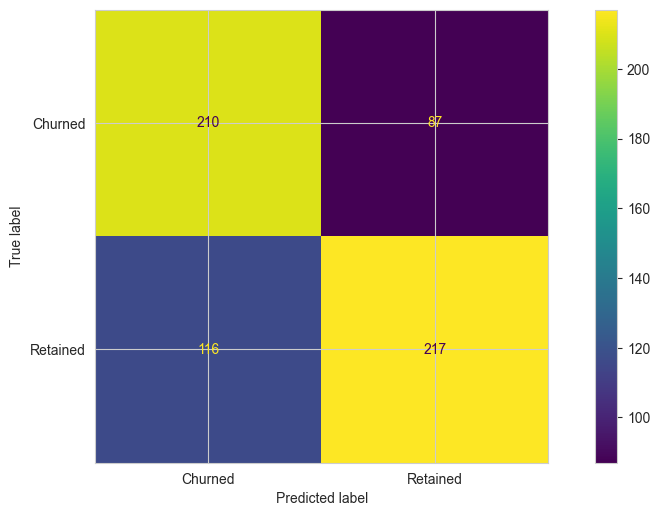


Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.65      0.68       333
           1       0.64      0.71      0.67       297

    accuracy                           0.68       630
   macro avg       0.68      0.68      0.68       630
weighted avg       0.68      0.68      0.68       630

ROC-AUC: 0.7276165053942831


In [86]:
log_preds = log_reg.predict(X_test)
log_probs = log_reg.predict_proba(X_test)[:, 1]

print("=== Logistic Regression (Scaled + Engineered Features) ===")
print("Confusion Matrix:")
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, log_preds, labels=[1, 0])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Churned", "Retained"])
disp.plot()
plt.show()
print("\nClassification Report:")
print(classification_report(y_test, log_preds))
print("ROC-AUC:", roc_auc_score(y_test, log_probs))


## Threshold Tuning

A 0.5 threshold isn't sacred. Missing a churner costs more than falsely flagging a loyal customer, a retention email is cheap, losing a customer isn't. So I sweep thresholds to find one that pushes churn recall to at least 80%, accepting some precision loss as the tradeoff.

Best threshold (max F1 for Churn): 0.285
  Precision: 0.568  |  Recall: 0.912  |  F1: 0.700

Threshold for ≥80% Churn Recall: 0.402
  Precision: 0.599  |  Recall: 0.801  |  F1: 0.686

=== Logistic Regression @ threshold=0.402 ===
Confusion Matrix:
[[174 159]
 [ 59 238]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.52      0.61       333
           1       0.60      0.80      0.69       297

    accuracy                           0.65       630
   macro avg       0.67      0.66      0.65       630
weighted avg       0.68      0.65      0.65       630

ROC-AUC: 0.7276165053942831


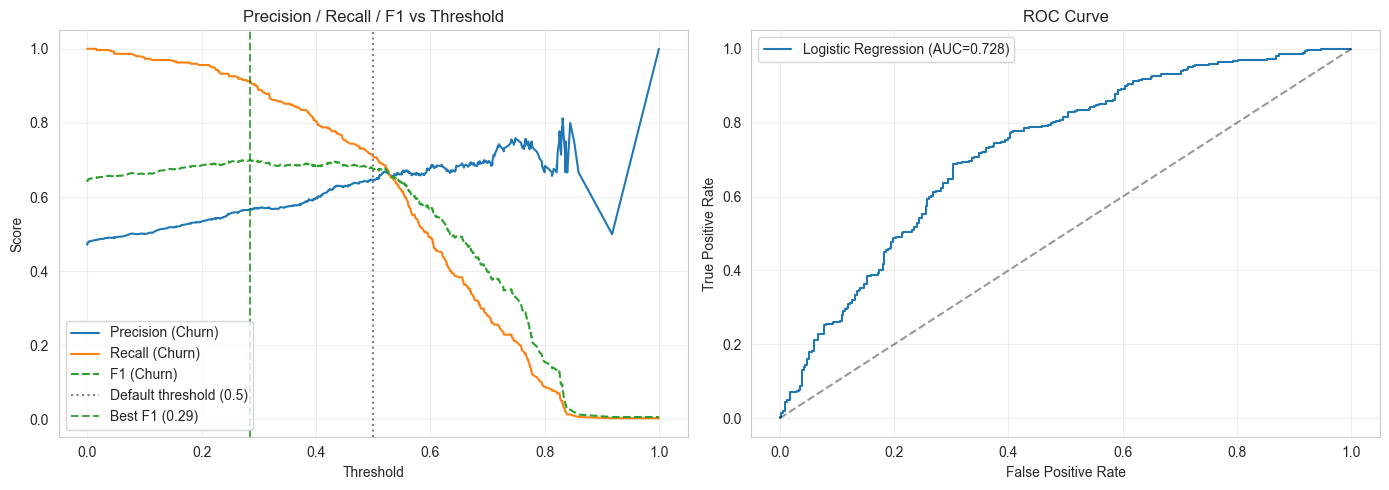

In [87]:
from sklearn.metrics import precision_recall_curve, f1_score

precisions, recalls, thresholds = precision_recall_curve(y_test, log_probs, pos_label=1)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, precisions[:-1], label="Precision (Churn)")
axes[0].plot(thresholds, recalls[:-1], label="Recall (Churn)")
axes[0].plot(thresholds, f1_scores[:-1], label="F1 (Churn)", linestyle="--")
axes[0].axvline(x=0.5, color="gray", linestyle=":", label="Default threshold (0.5)")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Precision / Recall / F1 vs Threshold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
print(f"Best threshold (max F1 for Churn): {best_threshold:.3f}")
print(f"  Precision: {precisions[best_idx]:.3f}  |  Recall: {recalls[best_idx]:.3f}  |  F1: {f1_scores[best_idx]:.3f}")

recall_target = 0.80
candidates = np.where(recalls[:-1] >= recall_target)[0]
if len(candidates) > 0:
    high_recall_idx = candidates[np.argmax(precisions[:-1][candidates])]
    high_recall_threshold = thresholds[high_recall_idx]
    print(f"\nThreshold for ≥{int(recall_target*100)}% Churn Recall: {high_recall_threshold:.3f}")
    print(f"  Precision: {precisions[high_recall_idx]:.3f}  |  Recall: {recalls[high_recall_idx]:.3f}  |  F1: {f1_scores[high_recall_idx]:.3f}")
else:
    high_recall_threshold = best_threshold
    print(f"\nCould not reach {int(recall_target*100)}% recall; using best F1 threshold instead.")

axes[0].axvline(x=best_threshold, color="green", linestyle="--", alpha=0.7, label=f"Best F1 ({best_threshold:.2f})")
axes[0].legend()

tuned_preds = (log_probs >= high_recall_threshold).astype(int)
print(f"\n=== Logistic Regression @ threshold={high_recall_threshold:.3f} ===")
print("Confusion Matrix:")
print(confusion_matrix(y_test, tuned_preds))
print("\nClassification Report:")
print(classification_report(y_test, tuned_preds))
print("ROC-AUC:", roc_auc_score(y_test, log_probs))

from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_test, log_probs)
axes[1].plot(fpr, tpr, label=f"Logistic Regression (AUC={auc(fpr, tpr):.3f})")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Model Comparison

Logistic regression gave me a baseline. Now I want to know if nonlinear models do better. Random Forest and Gradient Boosting can capture interactions that logistic regression misses, like "high spender AND long recency" being a different signal than either alone. I'm comparing on churn F1 specifically, not accuracy, since the classes are somewhat imbalanced.

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.71      0.65      0.68       333
           1       0.64      0.71      0.67       297

    accuracy                           0.68       630
   macro avg       0.68      0.68      0.68       630
weighted avg       0.68      0.68      0.68       630


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.68      0.68      0.68       333
           1       0.64      0.65      0.65       297

    accuracy                           0.67       630
   macro avg       0.66      0.66      0.66       630
weighted avg       0.67      0.67      0.67       630


=== Gradient Boosting ===
              precision    recall  f1-score   support

           0       0.69      0.67      0.68       333
           1       0.64      0.66      0.65       297

    accuracy                           0.66       630
   macro avg       0.66      0.66      0.66       

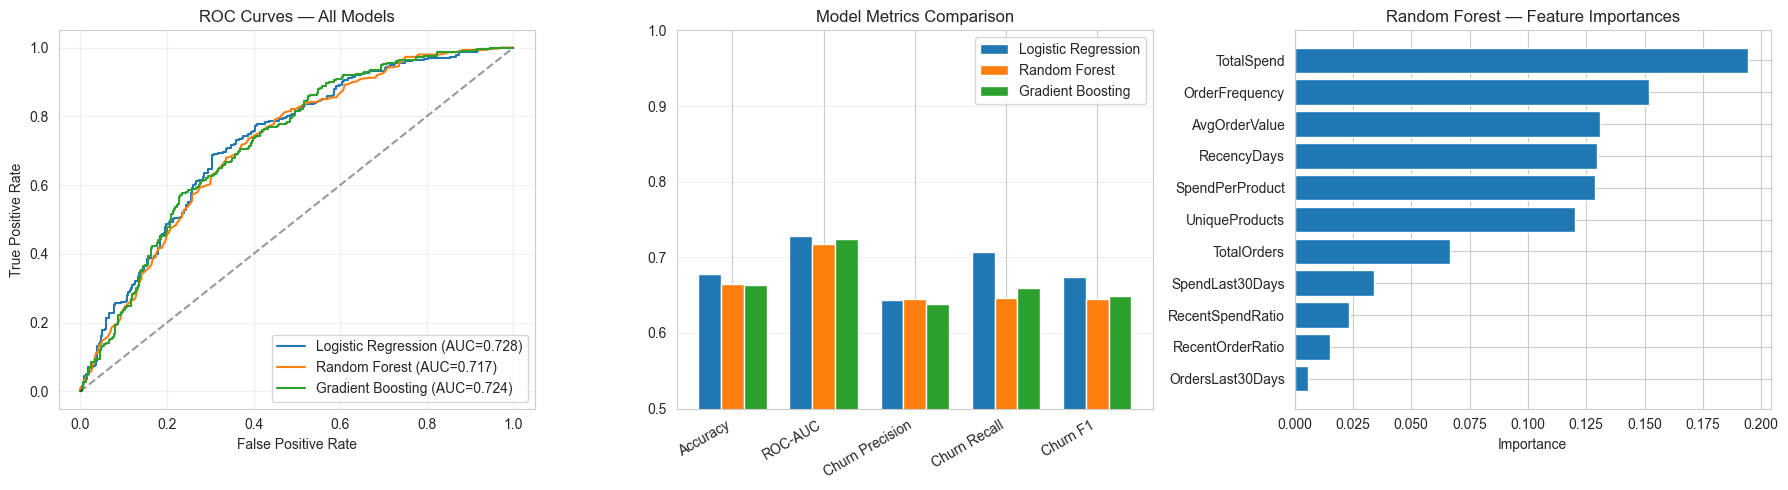


Best model by Churn F1: Logistic Regression (0.6742)


In [88]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)
gb.fit(X_train, y_train)

models = {
    "Logistic Regression": (log_reg, log_probs),
    "Random Forest": (rf, rf.predict_proba(X_test)[:, 1]),
    "Gradient Boosting": (gb, gb.predict_proba(X_test)[:, 1]),
}

results = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, (model, probs)) in enumerate(models.items()):
    preds = model.predict(X_test)
    acc = (preds == y_test).mean()
    auc_score = roc_auc_score(y_test, probs)
    report = classification_report(y_test, preds, output_dict=True)

    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "ROC-AUC": round(auc_score, 4),
        "Churn Precision": round(report["1"]["precision"], 4),
        "Churn Recall": round(report["1"]["recall"], 4),
        "Churn F1": round(report["1"]["f1-score"], 4),
    })

    fpr_m, tpr_m, _ = roc_curve(y_test, probs)
    axes[0].plot(fpr_m, tpr_m, label=f"{name} (AUC={auc_score:.3f})")

    print(f"=== {name} ===")
    print(classification_report(y_test, preds))
    print()

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves — All Models")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

comparison_df = pd.DataFrame(results).set_index("Model")
print(comparison_df.to_string())

metrics = ["Accuracy", "ROC-AUC", "Churn Precision", "Churn Recall", "Churn F1"]
x = np.arange(len(metrics))
width = 0.25

for j, model_name in enumerate(comparison_df.index):
    vals = comparison_df.loc[model_name, metrics].values.astype(float)
    axes[1].bar(x + j * width, vals, width, label=model_name)

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(metrics, rotation=30, ha="right")
axes[1].set_ylim(0.5, 1.0)
axes[1].set_title("Model Metrics Comparison")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

importances = rf.feature_importances_
sorted_idx = np.argsort(importances)
axes[2].barh(np.array(feature_cols)[sorted_idx], importances[sorted_idx])
axes[2].set_title("Random Forest — Feature Importances")
axes[2].set_xlabel("Importance")

plt.tight_layout()
plt.show()

best_model = comparison_df["Churn F1"].idxmax()
print(f"\nBest model by Churn F1: {best_model} ({comparison_df.loc[best_model, 'Churn F1']:.4f})")

## RFM Segmentation

I chose RFM because it's the standard customer segmentation approach in ecommerce and I can turn each segment into an action. I score each dimension into quartiles first, that gives me interpretable segments like "Champions" and "At Risk." I then run KMeans on the same data to see if the algorithm finds different natural groupings. Comparing the crosstab tells me whether my manual segments align with what the data actually says.

            Recency  Frequency  Monetary  R_Score  F_Score  M_Score RFM_Score  RFM_Total              Segment
CustomerID                                                                                                   
12346           326          1  77183.60        1        1        4       114          6  Potential Loyalists
12347             2          7   4310.00        4        4        4       444         12            Champions
12348            75          4   1797.24        2        3        4       234          9                Loyal
12349            19          1   1757.55        3        1        4       314          8                Loyal
12350           310          1    334.40        1        1        2       112          4                 Lost
12352            36          8   2506.04        3        4        4       344         11            Champions
12353           204          1     89.00        1        1        1       111          3                 Lost
12354     

/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/pandas/plotting/_matplotlib/tools.py:400: MatplotlibDeprecationWarning: 
The is_first_col function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_first_col() instead.
  if ax.is_first_col():


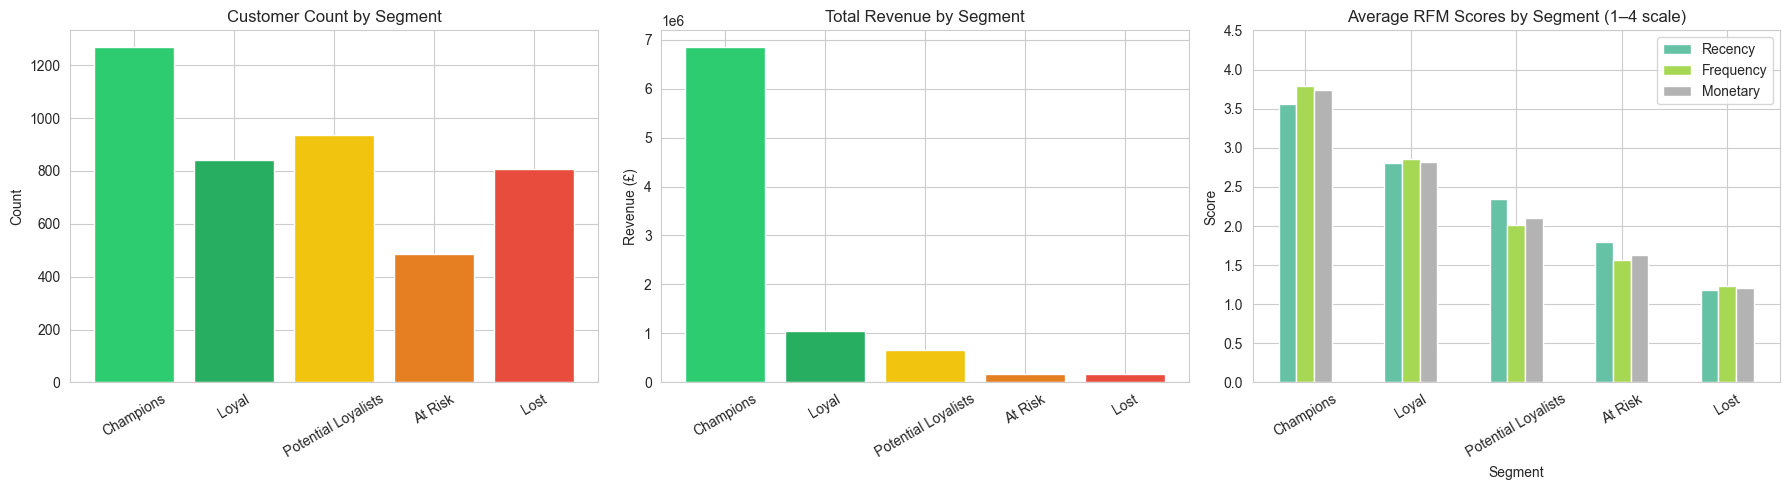

In [89]:
snapshot_date = clean_df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = clean_df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum')
)

rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4]).astype(int)

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Total'] = rfm[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

def rfm_segment(total):
    if total >= 10:
        return 'Champions'
    elif total >= 8:
        return 'Loyal'
    elif total >= 6:
        return 'Potential Loyalists'
    elif total >= 5:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm['RFM_Total'].apply(rfm_segment)

print(rfm.head(10).to_string())
print(f"\n--- Segment Distribution ---")
print(rfm['Segment'].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
segment_order = ['Champions', 'Loyal', 'Potential Loyalists', 'At Risk', 'Lost']
colors = ['#2ecc71', '#27ae60', '#f1c40f', '#e67e22', '#e74c3c']

segment_counts = rfm['Segment'].value_counts().reindex(segment_order)
axes[0].bar(segment_counts.index, segment_counts.values, color=colors)
axes[0].set_title('Customer Count by Segment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

segment_revenue = rfm.groupby('Segment')['Monetary'].sum().reindex(segment_order)
axes[1].bar(segment_revenue.index, segment_revenue.values, color=colors)
axes[1].set_title('Total Revenue by Segment')
axes[1].set_ylabel('Revenue (£)')
axes[1].tick_params(axis='x', rotation=30)

segment_avg = rfm.groupby('Segment')[['R_Score', 'F_Score', 'M_Score']].mean().reindex(segment_order)
segment_avg.plot(kind='bar', ax=axes[2], colormap='Set2')
axes[2].set_title('Average RFM Scores by Segment (1–4 scale)')
axes[2].set_ylabel('Score')
axes[2].set_ylim(0, 4.5)
axes[2].tick_params(axis='x', rotation=30)
axes[2].legend(['Recency', 'Frequency', 'Monetary'], loc='upper right')

plt.tight_layout()
plt.show()

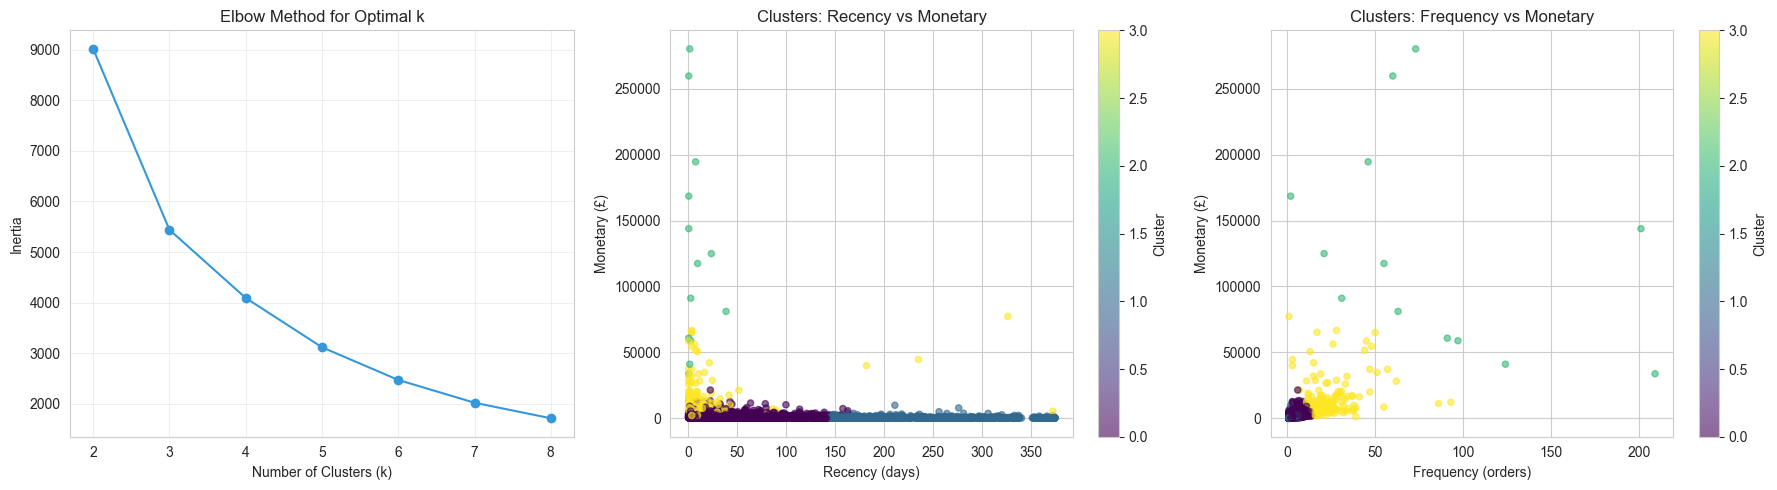

=== K-Means Cluster Summary ===
         Count  Avg_Recency  Avg_Frequency  Avg_Monetary
Cluster                                                 
0         3054        43.70           3.68       1359.05
1         1067       248.08           1.55        480.62
2           13         7.38          82.54     127338.31
3          204        15.50          22.33      12709.09

=== Cluster ↔ RFM Segment Crosstab ===
Segment  At Risk  Champions  Lost  Loyal  Potential Loyalists
Cluster                                                      
0            292        292   292    292                  292
1            292          0   292    292                  292
2              0        292     0      0                    0
3              0        292     0    292                  292


In [90]:
from sklearn.cluster import KMeans

rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]
scaler_rfm = StandardScaler()
rfm_scaled = scaler_rfm.fit_transform(rfm_features)

inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(list(K_range), inertias, 'o-', color='#3498db')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method for Optimal k')
axes[0].grid(True, alpha=0.3)

optimal_k = 4
km_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(rfm_scaled)

scatter = axes[1].scatter(
    rfm['Recency'], rfm['Monetary'],
    c=rfm['Cluster'], cmap='viridis', alpha=0.6, s=20
)
axes[1].set_xlabel('Recency (days)')
axes[1].set_ylabel('Monetary (£)')
axes[1].set_title('Clusters: Recency vs Monetary')
plt.colorbar(scatter, ax=axes[1], label='Cluster')

scatter2 = axes[2].scatter(
    rfm['Frequency'], rfm['Monetary'],
    c=rfm['Cluster'], cmap='viridis', alpha=0.6, s=20
)
axes[2].set_xlabel('Frequency (orders)')
axes[2].set_ylabel('Monetary (£)')
axes[2].set_title('Clusters: Frequency vs Monetary')
plt.colorbar(scatter2, ax=axes[2], label='Cluster')

plt.tight_layout()
plt.show()

cluster_summary = rfm.groupby('Cluster').agg(
    Count=('Recency', 'size'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
).round(2)

print("=== K-Means Cluster Summary ===")
print(cluster_summary.to_string())

print("\n=== Cluster ↔ RFM Segment Crosstab ===")
print(pd.crosstab(rfm['Cluster'], rfm['Segment']))

## Market Basket Analysis

I'm looking for products frequently bought together, exactly what you need for product recommendations. I filtered to UK only and the top 50 products because the full product matrix is too sparse for Apriori to find meaningful patterns. Lift is the metric I care about most: a lift of 3 means two products appear together 3x more often than chance. Support and confidence alone can be misleading.

Basket matrix shape: 11085 invoices × 50 products
Frequent itemsets found: 44
Association rules found: 12

=== Top 15 Association Rules (by Lift) ===
                   antecedents                    consequents  support  confidence     lift
          JUMBO BAG STRAWBERRY        JUMBO BAG RED RETROSPOT 0.035634    0.635048 4.864900
       JUMBO BAG RED RETROSPOT           JUMBO BAG STRAWBERRY 0.035634    0.272979 4.864900
       LUNCH BAG  BLACK SKULL.        LUNCH BAG RED RETROSPOT 0.043663    0.485944 4.809542
       LUNCH BAG RED RETROSPOT        LUNCH BAG  BLACK SKULL. 0.043663    0.432143 4.809542
       JUMBO BAG PINK POLKADOT        JUMBO BAG RED RETROSPOT 0.045647    0.623153 4.773772
       JUMBO BAG RED RETROSPOT        JUMBO BAG PINK POLKADOT 0.045647    0.349689 4.773772
       JUMBO BAG RED RETROSPOT         JUMBO STORAGE BAG SUKI 0.036806    0.281963 4.341050
        JUMBO STORAGE BAG SUKI        JUMBO BAG RED RETROSPOT 0.036806    0.566667 4.341050
JUMBO  BAG BAROQUE BLA

/Users/mohityadav/Library/Python/3.8/lib/python/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


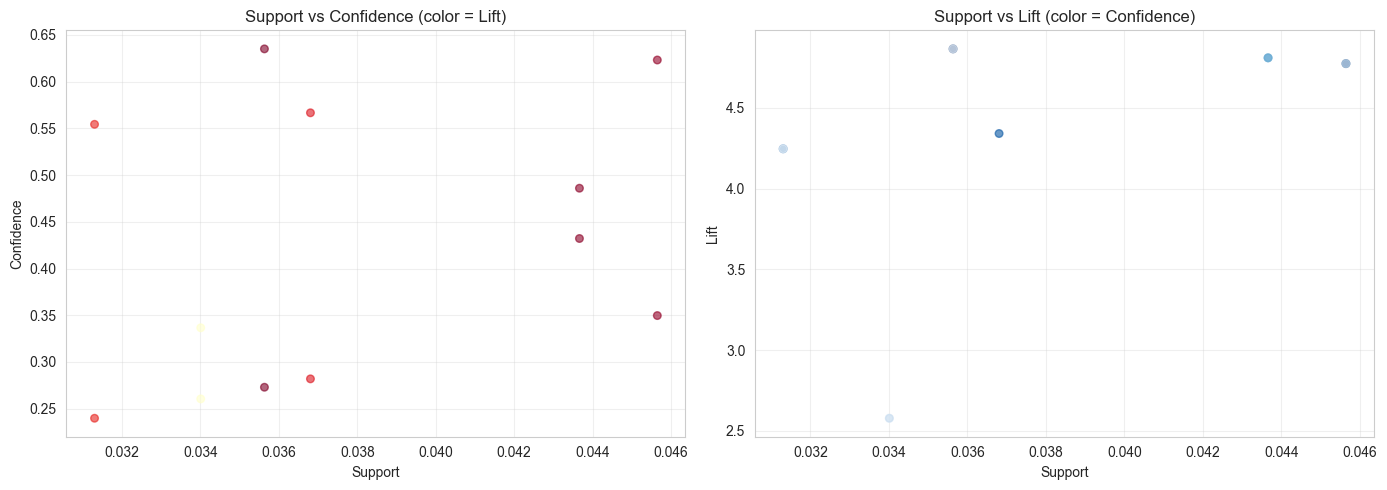

In [91]:
from mlxtend.frequent_patterns import apriori, association_rules

uk_df = clean_df[clean_df['Country'] == 'United Kingdom'].copy()

top_products = (
    uk_df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(50)
    .index
)
uk_df = uk_df[uk_df['Description'].isin(top_products)]

basket = (
    uk_df.groupby(['InvoiceNo', 'Description'])['Quantity']
    .sum()
    .unstack()
    .fillna(0)
)
basket = (basket > 0).astype(int)

print(f"Basket matrix shape: {basket.shape[0]} invoices × {basket.shape[1]} products")

frequent_items = apriori(basket, min_support=0.03, use_colnames=True)
print(f"Frequent itemsets found: {len(frequent_items)}")

rules = association_rules(frequent_items, metric="lift", min_threshold=1.0)
rules = rules.sort_values('lift', ascending=False)
print(f"Association rules found: {len(rules)}\n")

top_rules = rules.head(15)[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
top_rules['antecedents'] = top_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
top_rules['consequents'] = top_rules['consequents'].apply(lambda x: ', '.join(list(x)))
print("=== Top 15 Association Rules (by Lift) ===")
print(top_rules.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(rules['support'], rules['confidence'], c=rules['lift'], cmap='YlOrRd', alpha=0.6, s=30)
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Confidence')
axes[0].set_title('Support vs Confidence (color = Lift)')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(rules['support'], rules['lift'], c=rules['confidence'], cmap='Blues', alpha=0.6, s=30)
axes[1].set_xlabel('Support')
axes[1].set_ylabel('Lift')
axes[1].set_title('Support vs Lift (color = Confidence)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Cohort Retention

I group customers by their first purchase month and track how many return in each subsequent month. Churn prediction can't answer one key question: is retention getting better or worse over time? If newer cohorts retain worse than older ones, that's a structural problem. If a single cohort drops off, something happened that month. One look at the heatmap makes both patterns visible.

/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


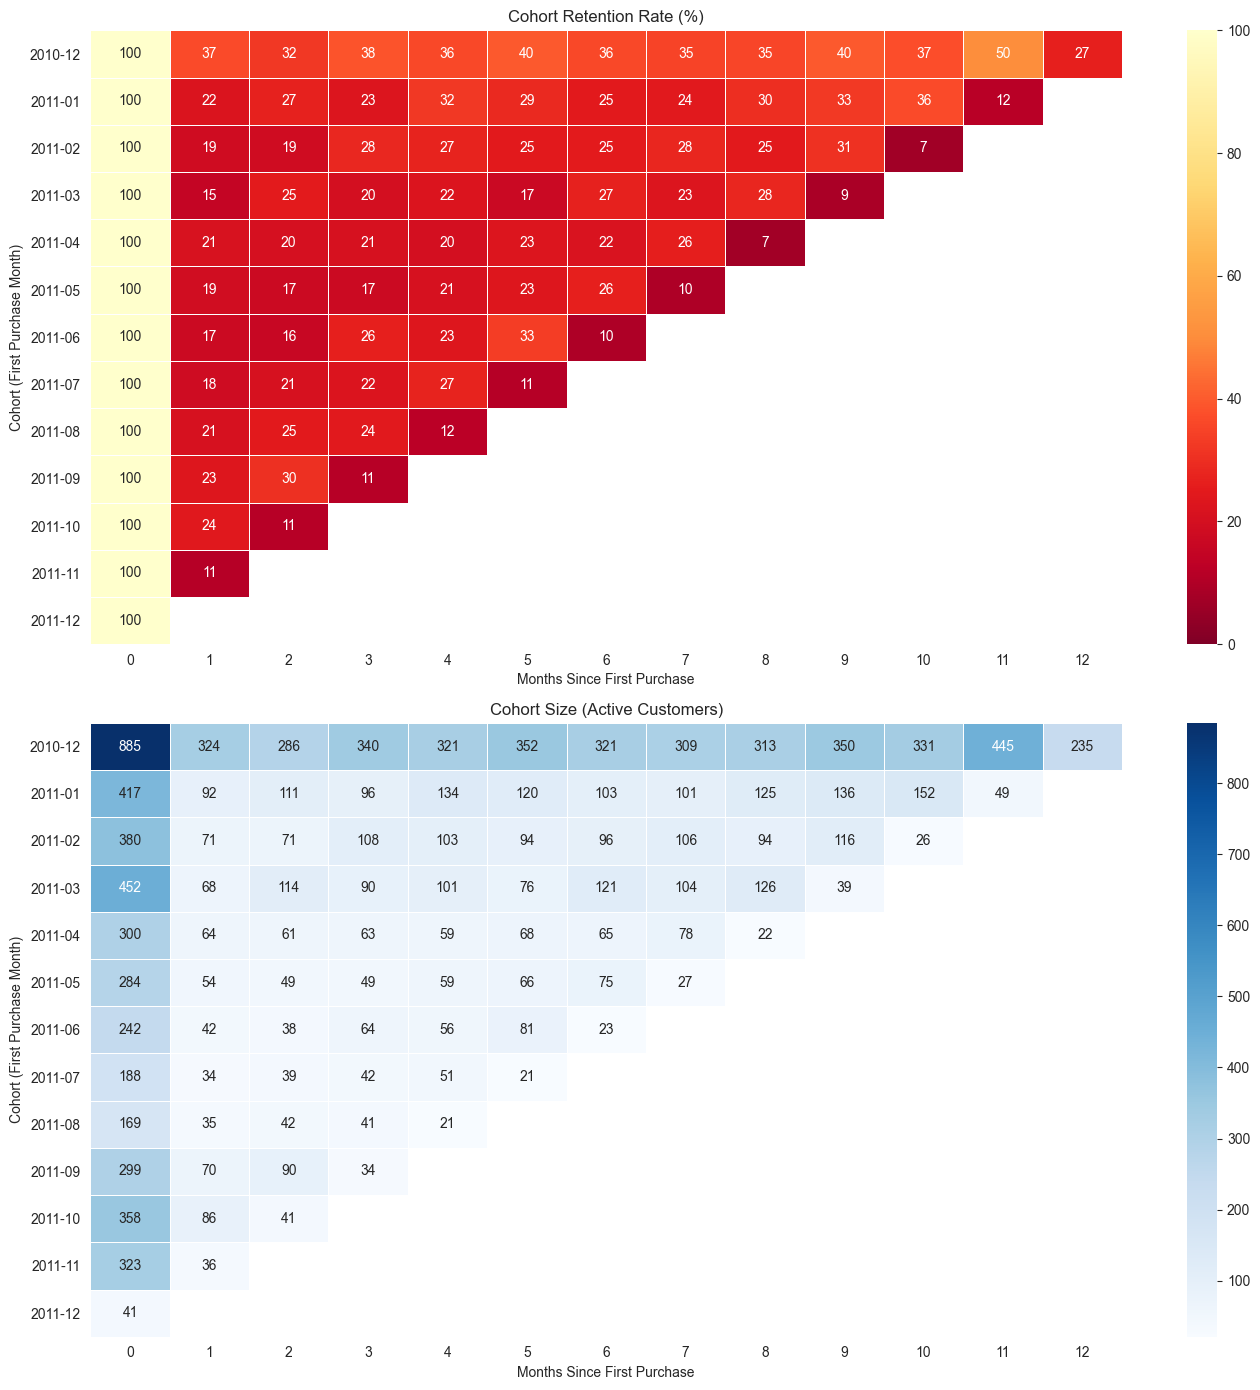

=== Cohort Sizes (Month 0) ===
CohortMonth
2010-12    885.0
2011-01    417.0
2011-02    380.0
2011-03    452.0
2011-04    300.0
2011-05    284.0
2011-06    242.0
2011-07    188.0
2011-08    169.0
2011-09    299.0
2011-10    358.0
2011-11    323.0
2011-12     41.0
Freq: M

=== Average Retention by Month ===
  Month 1: 20.6%
  Month 2: 22.1%
  Month 3: 23.2%
  Month 4: 24.6%
  Month 5: 25.1%
  Month 6: 24.4%
  Month 7: 24.3%
  Month 8: 25.1%
  Month 9: 27.8%
  Month 10: 26.9%
  Month 11: 31.0%
  Month 12: 26.6%


In [92]:
cohort_df = clean_df.copy()
cohort_df['InvoiceMonth'] = cohort_df['InvoiceDate'].dt.to_period('M')

first_purchase = cohort_df.groupby('CustomerID')['InvoiceMonth'].min().rename('CohortMonth')
cohort_df = cohort_df.merge(first_purchase, on='CustomerID')

cohort_df['PeriodNumber'] = (
    cohort_df['InvoiceMonth'] - cohort_df['CohortMonth']
).apply(lambda x: x.n)

cohort_table = (
    cohort_df.groupby(['CohortMonth', 'PeriodNumber'])['CustomerID']
    .nunique()
    .reset_index()
)
cohort_table.columns = ['CohortMonth', 'PeriodNumber', 'Customers']

cohort_pivot = cohort_table.pivot(index='CohortMonth', columns='PeriodNumber', values='Customers')

cohort_sizes = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_sizes, axis=0) * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 14))

sns.heatmap(
    retention, annot=True, fmt='.0f', cmap='YlOrRd_r',
    ax=axes[0], vmin=0, vmax=100, linewidths=0.5
)
axes[0].set_title('Cohort Retention Rate (%)')
axes[0].set_xlabel('Months Since First Purchase')
axes[0].set_ylabel('Cohort (First Purchase Month)')

sns.heatmap(
    cohort_pivot, annot=True, fmt='.0f', cmap='Blues',
    ax=axes[1], linewidths=0.5
)
axes[1].set_title('Cohort Size (Active Customers)')
axes[1].set_xlabel('Months Since First Purchase')
axes[1].set_ylabel('Cohort (First Purchase Month)')

plt.tight_layout()
plt.show()

print("=== Cohort Sizes (Month 0) ===")
print(cohort_sizes.to_string())

avg_retention = retention.iloc[:, 1:].mean()
print("\n=== Average Retention by Month ===")
for month, rate in avg_retention.items():
    print(f"  Month {month}: {rate:.1f}%")